## get all similarities

We load the label name or description of all the nodes in the AI graph.


In [18]:
embedding_model_id = "all-MiniLM-L6-v2"



from sentence_transformers import SentenceTransformer, util
import torch

import pandas as pd

from metadata_schemas.acm_ccs_v2 import CCS_HIERARCHY as ai_terms
ai_terms = str(ai_terms).split("'")[1::2]


embedding_model = SentenceTransformer(embedding_model_id, device="cuda:1" if torch.cuda.device_count()>1 else "cuda:0")
ai_term_embedding = embedding_model.encode(ai_terms)

In [6]:
from dataset_loader import Arxiv_HF_datasets
ahd = Arxiv_HF_datasets()
ahd.prepare()
hf_df, arx_df = ahd.sample_subsets(100)
hf_df = hf_df.set_index("modelId")


/home/sondre/profile/llmdap/profiler/dataset_loader.py:448: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.arx = self.arx[self.arx["bin"]>=bin_range[0]][self.arx["bin"]<=bin_range[1]]


In [10]:
hf_dict, arx_dict = ahd.get_dict_format(100)

In [14]:
arx_df

,title,categories,abstract,submission_date,authors_parsed,bin
id,,,,,,
2203.15366,Face segmentation: A comparison between visibl...,cs.CV,Face segmentation is a first step for face b...,2022-03-29 09:02:45,"[['Mekyska', 'Jiri', ''], ['Espinosa-Duró', 'V...",2022.03
2204.00062,SimPO: Simultaneous Prediction and Optimization,cs.LG,Many machine learning (ML) models are integr...,2022-03-31 20:01:36,"[['Zhang', 'Bing', ''], ['Ong', 'Yuya Jeremy',...",2022.03
2203.05340,Domain Generalization via Shuffled Style Assem...,cs.CV,With diverse presentation attacks emerging c...,2022-03-10 12:44:05,"[['Wang', 'Zhuo', ''], ['Wang', 'Zezheng', '']...",2022.03
2203.01193,VAE-iForest: Auto-encoding Reconstruction and ...,cs.CV,"In road monitoring, it is an important issue...",2022-03-02 15:47:36,"[['Yasuno', 'Takato', ''], ['Fujii', 'Junichir...",2022.03
2203.16130,Sensor Data Validation and Driving Safety in A...,cs.CV,Autonomous driving technology has drawn a lo...,2022-03-30 08:17:14,"[['Zhang', 'Jindi', '']]",2022.03
...,...,...,...,...,...,...
2509.08522,RoboMatch: A Unified Mobile-Manipulation Teleo...,cs.RO,"This paper presents RoboMatch, a novel unified...",2025-09-10 12:00:21,"[['Liu', 'Hanyu', ''], ['Ma', 'Yunsheng', ''],...",2025.09
2509.07335,G3CN: Gaussian Topology Refinement Gated Graph...,cs.CV,Graph Convolutional Networks (GCNs) have prove...,2025-09-09 02:19:24,"[['Ren', 'Haiqing', ''], ['Luo', 'Zhongkai', '...",2025.09
2509.04094,Object-Reconstruction-Aware Whole-body Control...,cs.RO,Object reconstruction and inspection tasks pla...,2025-09-04 10:52:27,"[['Dursun', 'Fatih', ''], ['Adorno', 'Bruno Vi...",2025.09


In [15]:
hf_df["text"] = ""
arx_df["text"] = ""

for modelId in hf_df.index:
    hf_df.loc[modelId, "text"] = hf_dict[modelId.replace("/", "__")]
for paperid in arx_df.index:
    arx_df.loc[paperid, "text"] = arx_dict[paperid]


In [ ]:

arx_strings = arx_df["text"].to_list()
paper_embeddings = embedding_model.encode(arx_strings)
arx_similarities = util.cos_sim(paper_embeddings, ai_term_embedding)


model_embeddings = embedding_model.encode(hf_df["text"].to_list())
hf_similarities = util.cos_sim(model_embeddings, ai_term_embedding)



In [20]:
arx_similarities.shape, hf_similarities.shape

(torch.Size([4300, 155]), torch.Size([4300, 155]))

In [23]:
import torch
k = 10 # try out differnt values

def get_topk_indices_per_row(tensor: torch.Tensor, k: int = 5) -> torch.Tensor:
    """
    Returns the column indices of the top-k values in each row of the input tensor.

    Args:
        tensor (torch.Tensor): A 2D tensor of shape (num_rows, num_columns).
        k (int): Number of top values to retrieve per row.

    Returns:
        torch.Tensor: A 2D tensor of shape (num_rows, k) containing the column indices.
    """
    _, indices = torch.topk(tensor, k=k, dim=1)
    return indices

top_k_topics_per_paper = get_topk_indices_per_row(arx_similarities, k=k)

In [34]:
(top_k_topics_per_paper==89).any(axis=1).shape

torch.Size([4300])

In [30]:
ai_terms.index("Foundation models")

2

In [29]:
ai_terms[:10]

['Computing methodologies',
 'Artificial intelligence',
 'Foundation models',
 'Transformer architectures',
 'Attention mechanisms',
 'Large language models',
 'Vision-language models',
 'Multimodal foundation models',
 'Retrieval-augmented generation',
 'Instruction tuning and alignment']

In [44]:
k=1
term = "Foundation models"
term_index = ai_terms.index(term)

arx_topk = get_topk_indices_per_row(arx_similarities, k=k)
arx_mask = (top_k_topics_per_paper==term_index).any(axis=1)

hf_topk = get_topk_indices_per_row(hf_similarities, k=k)
hf_mask = (top_k_topics_per_paper==term_index).any(axis=1)

hf_df["mask"] = hf_mask
arx_df["mask"] = arx_mask

hf_dates = hf_df[hf_df["mask"]]["createdAt"]
arx_dates = arx_df[arx_df["mask"]]["submission_date"]


In [51]:
from matplotlib import pyplot as plt
def plot_term(term,k):

    term_index = ai_terms.index(term)

    arx_topk = get_topk_indices_per_row(arx_similarities, k=k)
    arx_mask = (arx_topk==term_index).any(axis=1)

    hf_topk = get_topk_indices_per_row(hf_similarities, k=k)
    hf_mask = (hf_topk==term_index).any(axis=1)


    hf_df["mask"] = hf_mask
    arx_df["mask"] = arx_mask

    hf_dates = hf_df[hf_df["mask"]]["createdAt"]
    arx_dates = arx_df[arx_df["mask"]]["submission_date"]


    if len(arx_dates)+len(hf_dates)<100:
        return
    plt.hist(arx_dates, bins=20, label="arx")
    plt.hist(hf_dates, bins=20, alpha=0.6, label="HF")
    plt.title(term)
    plt.legend()
    plt.show()

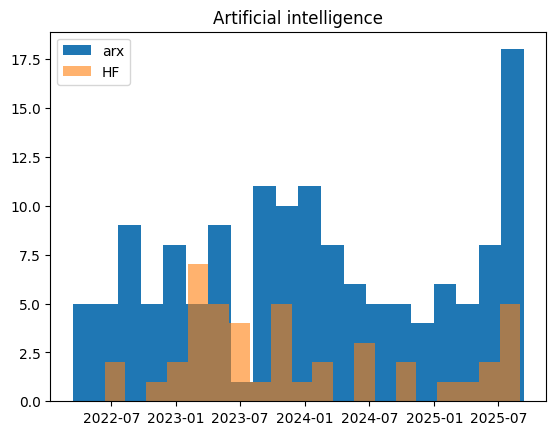

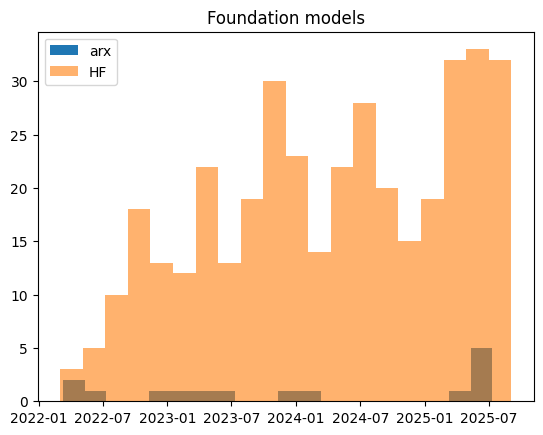

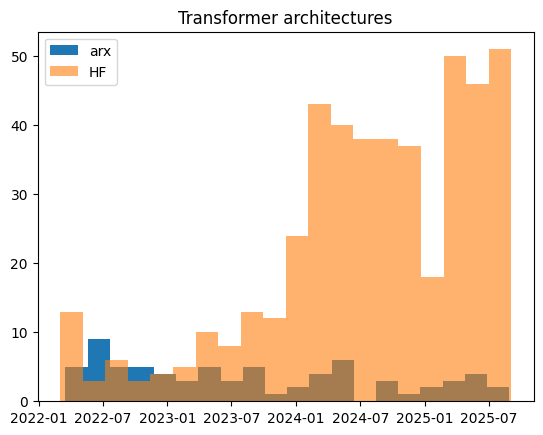

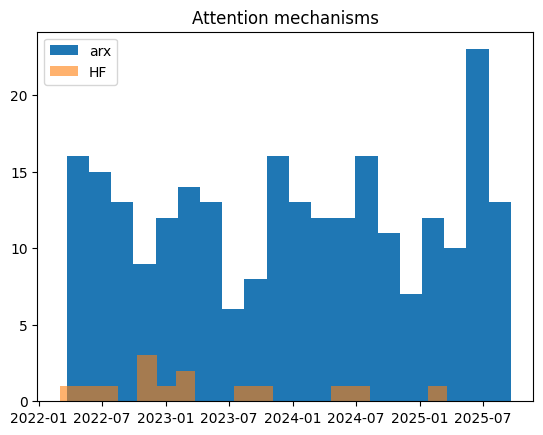

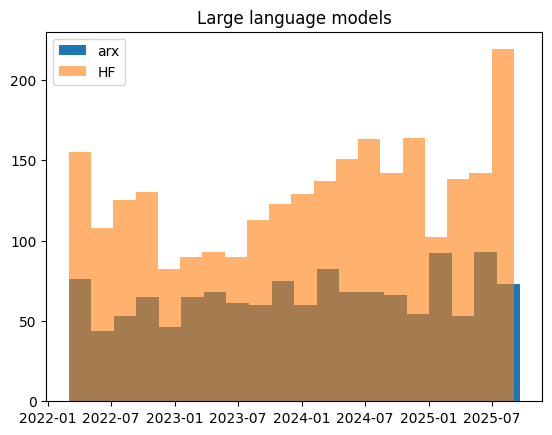

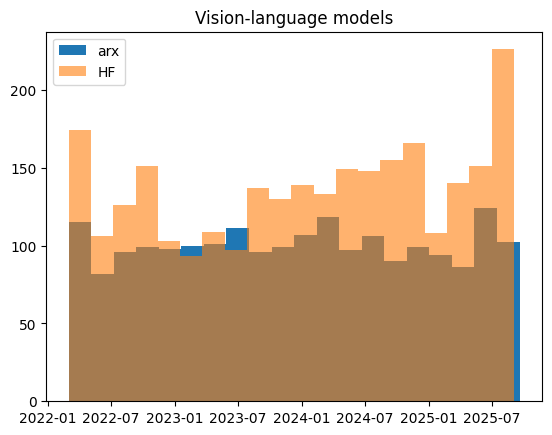

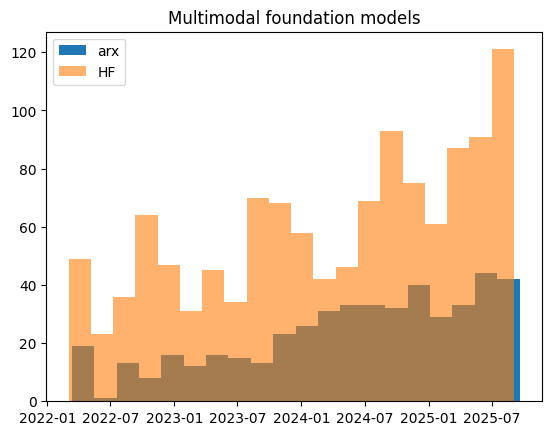

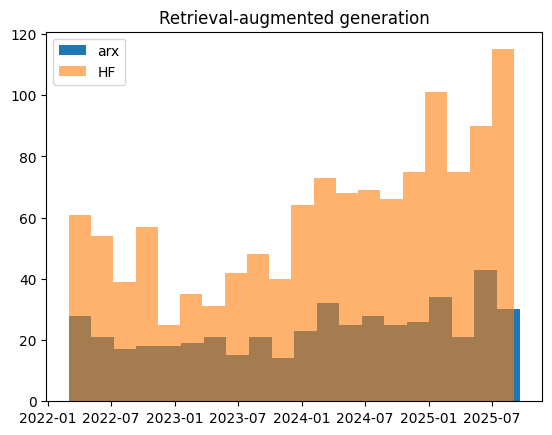

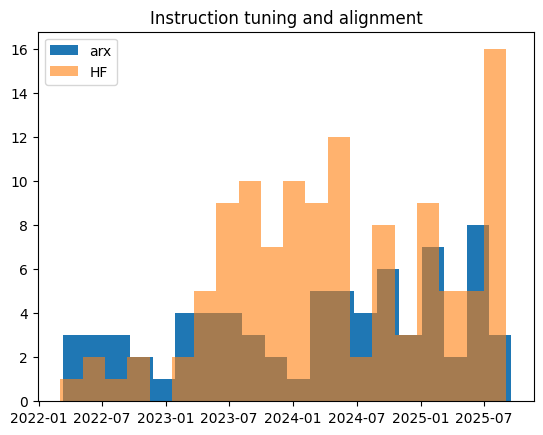

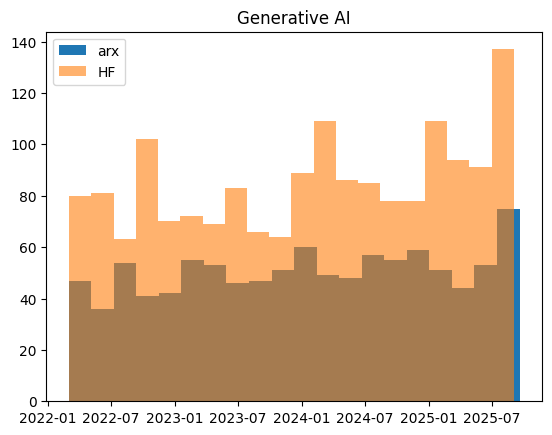

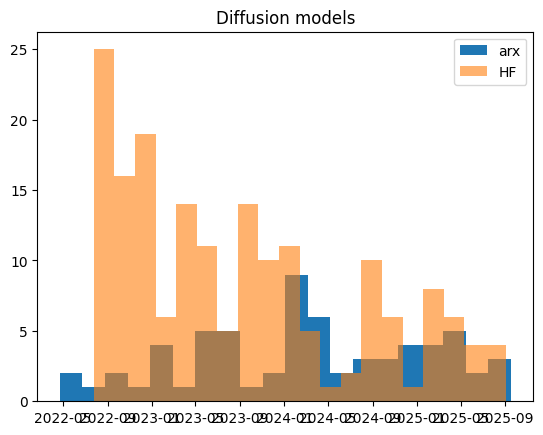

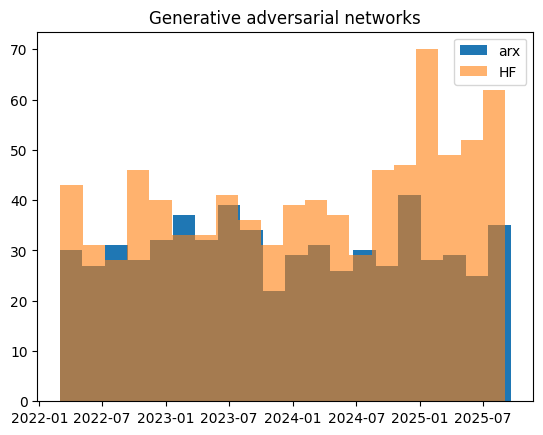

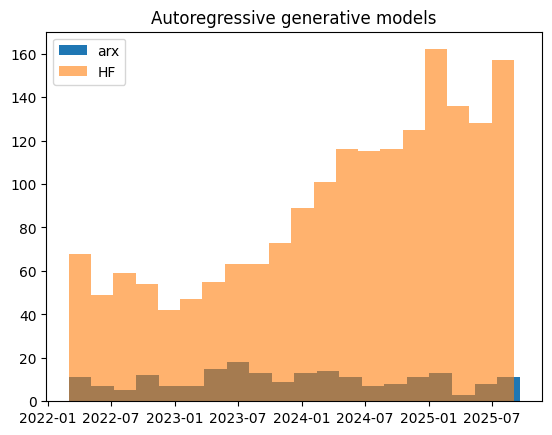

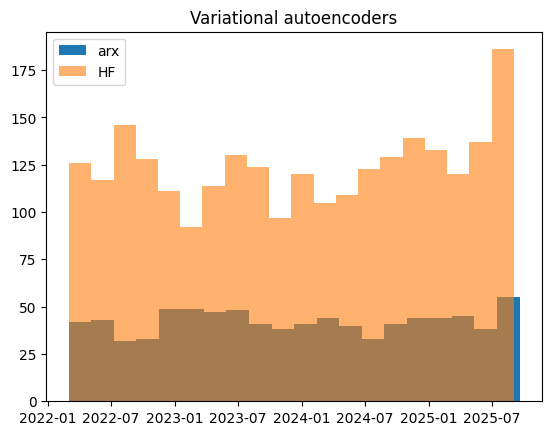

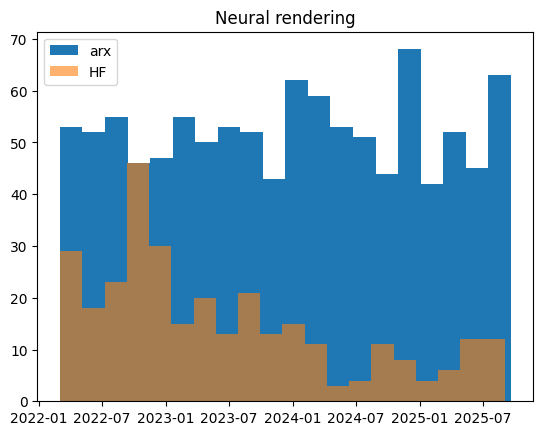

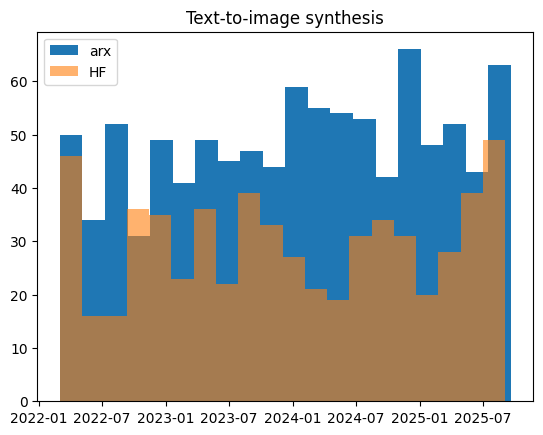

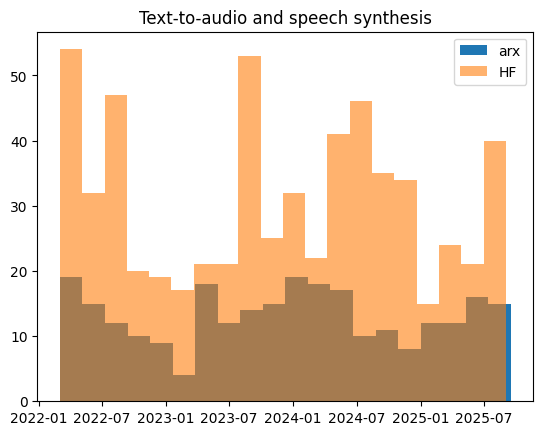

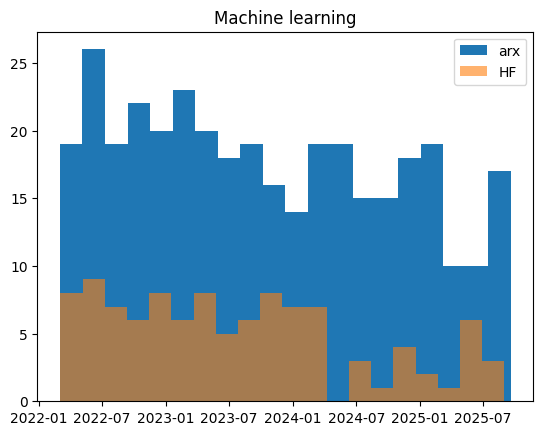

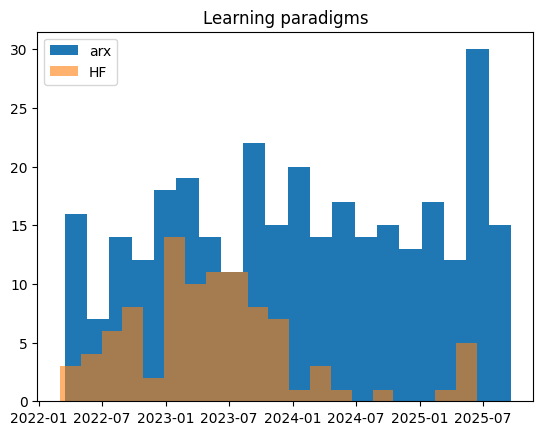

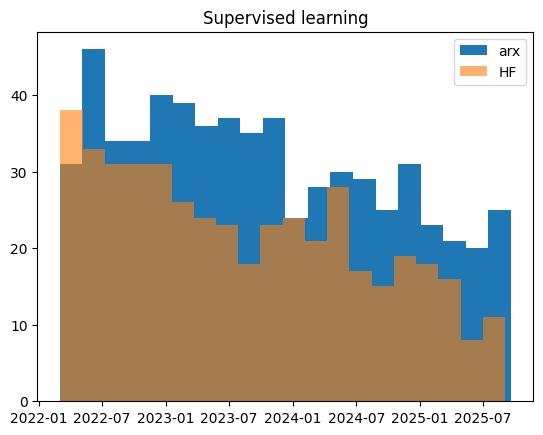

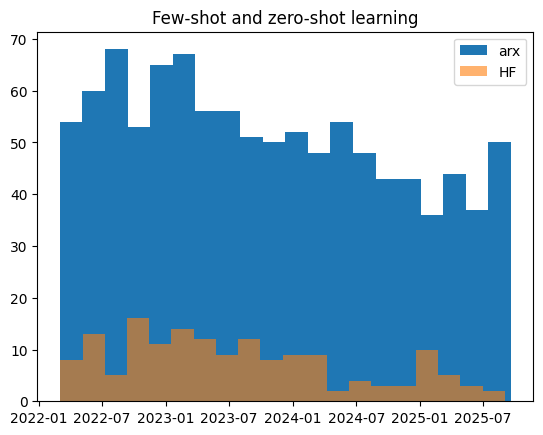

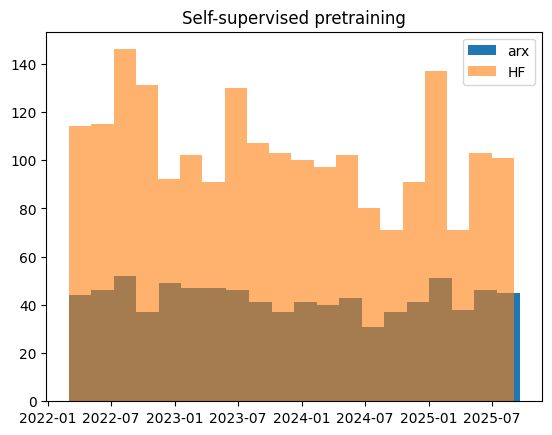

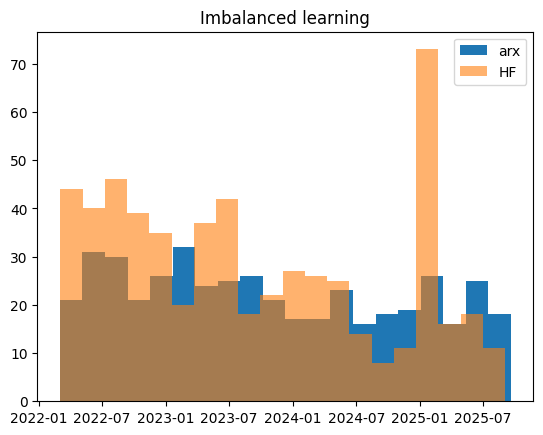

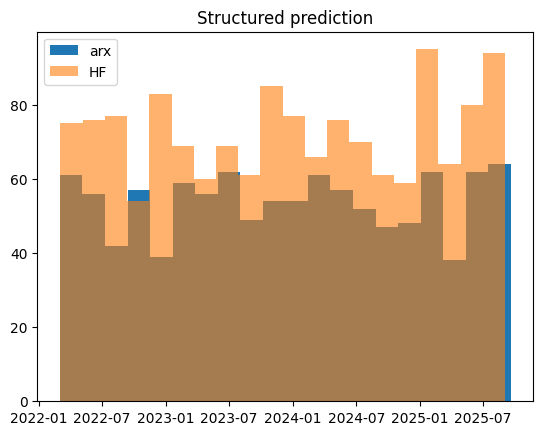

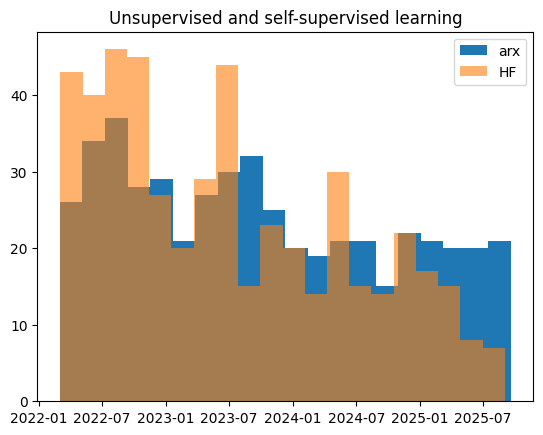

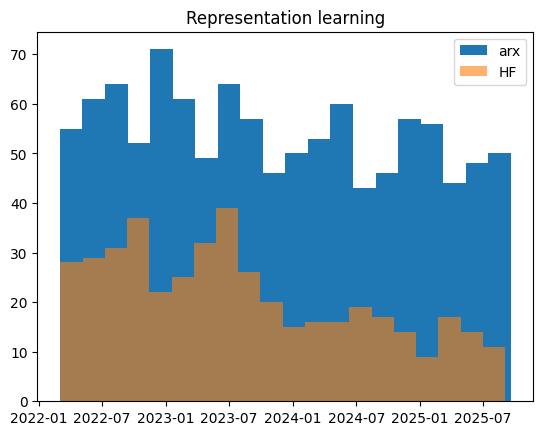

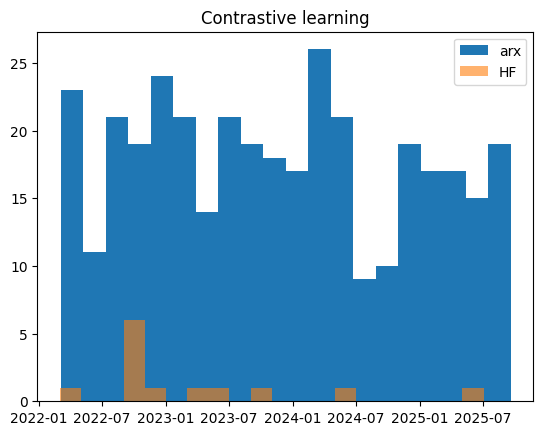

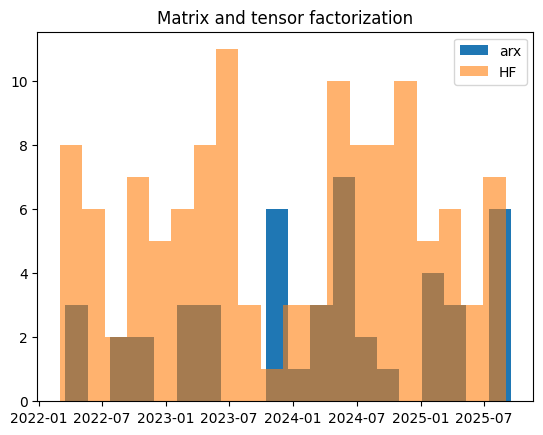

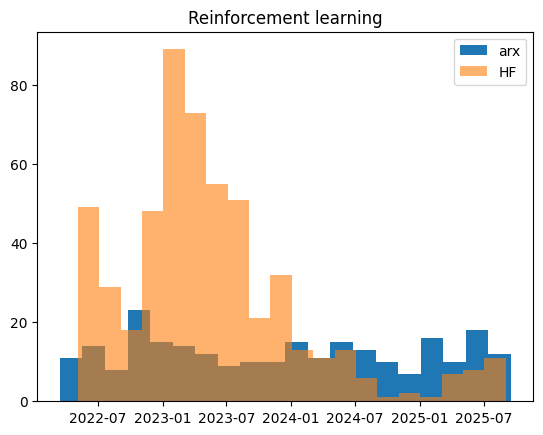

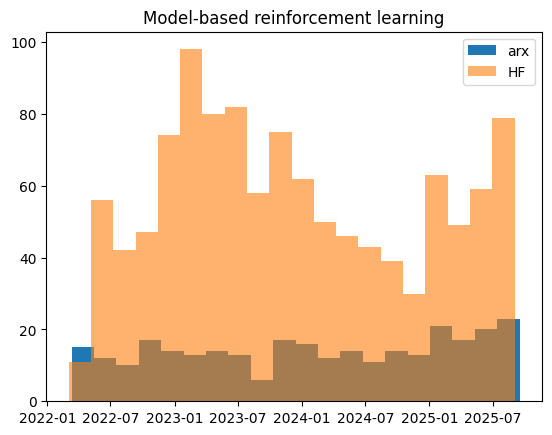

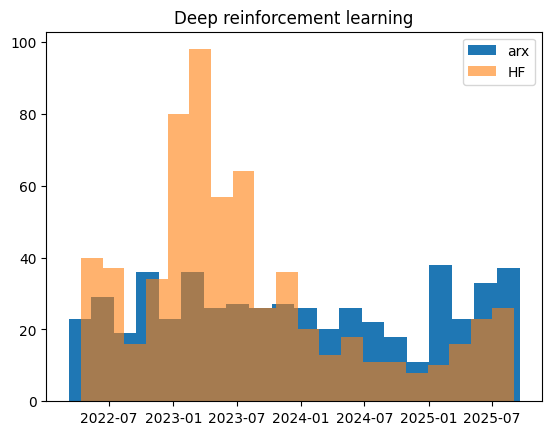

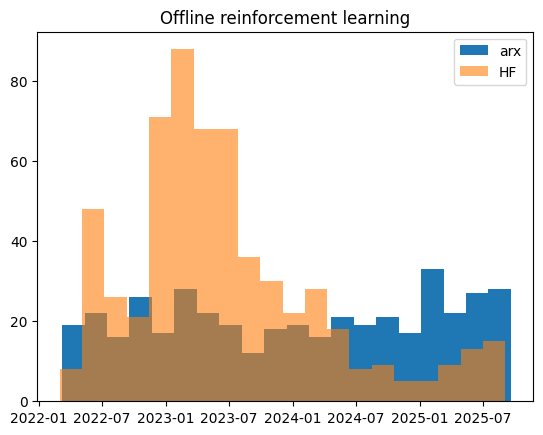

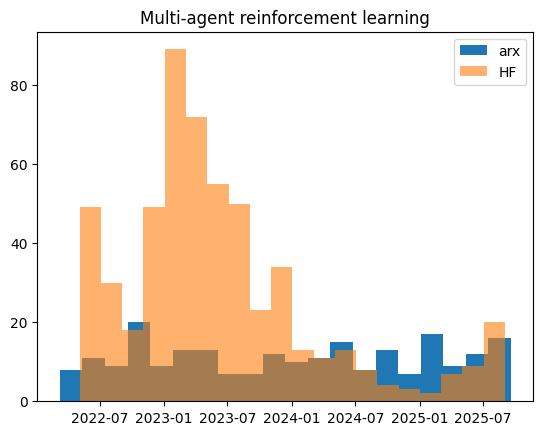

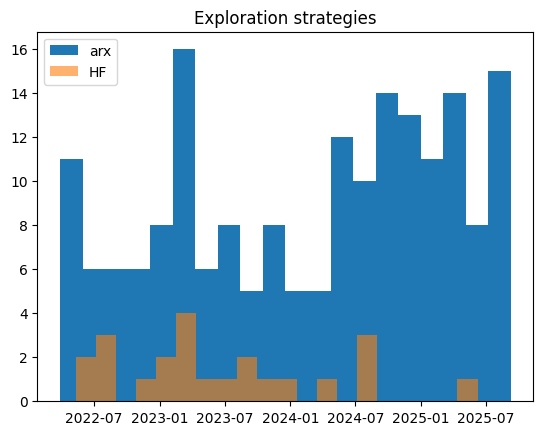

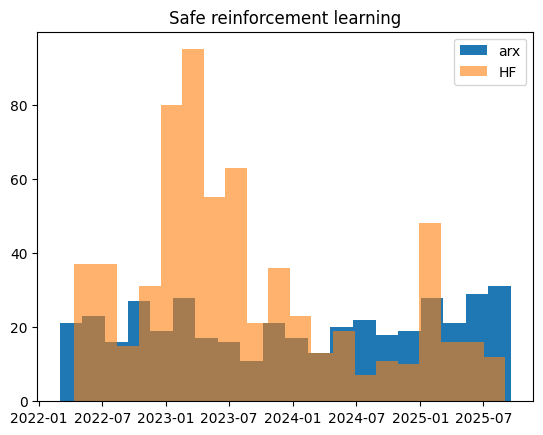

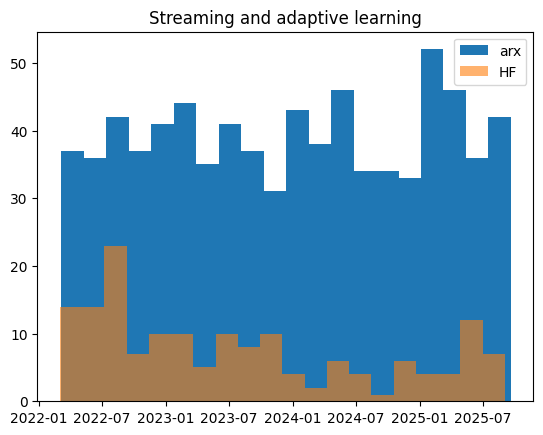

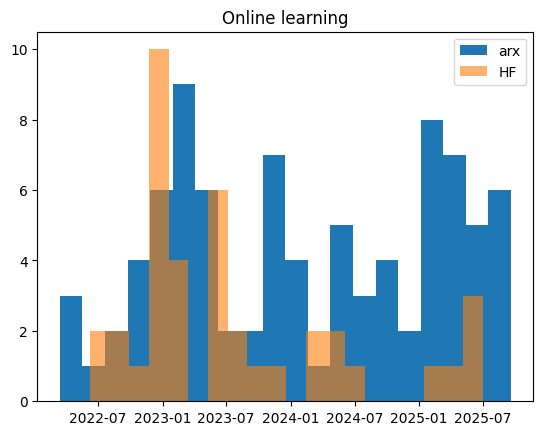

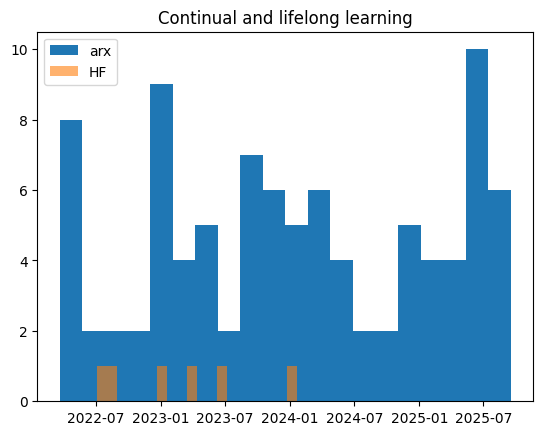

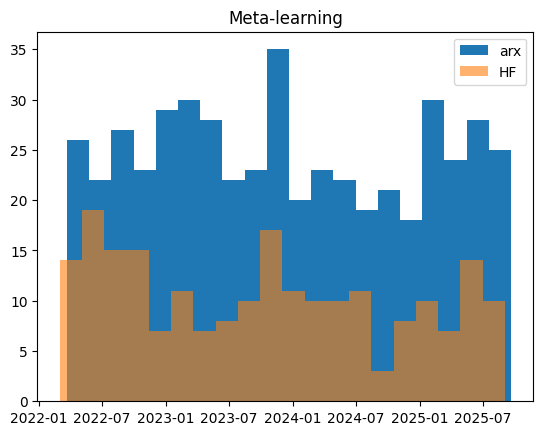

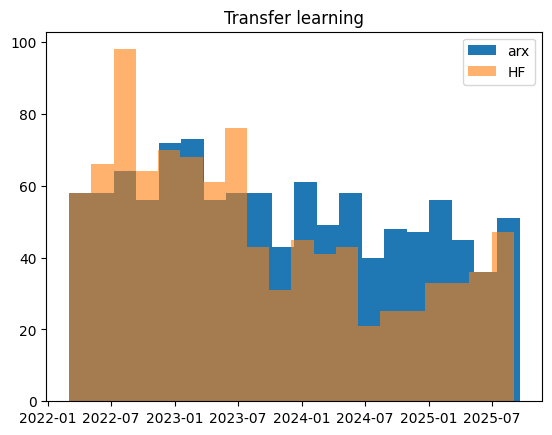

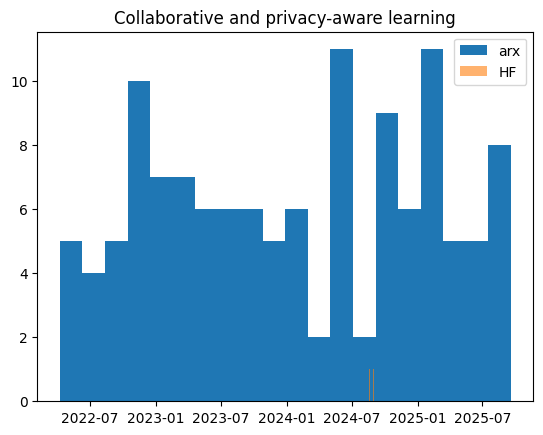

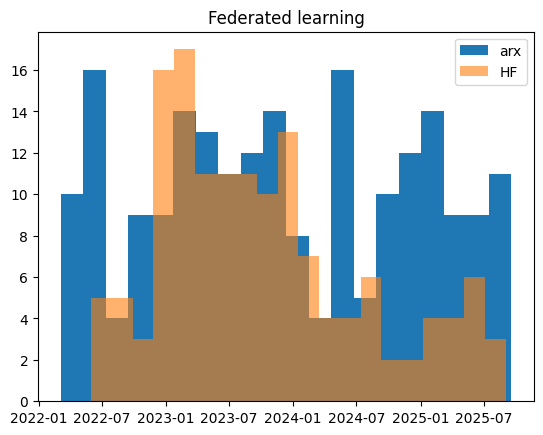

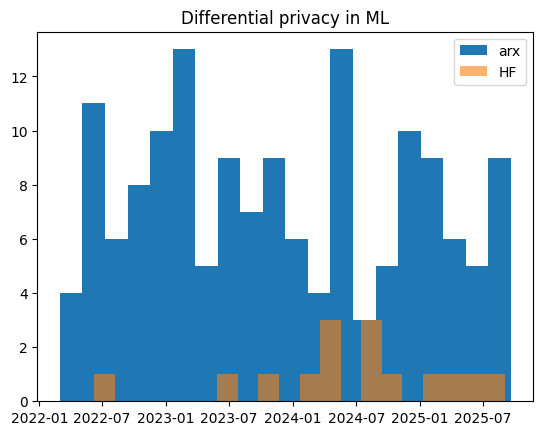

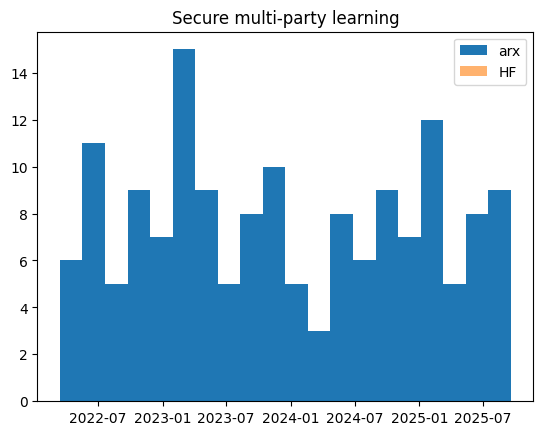

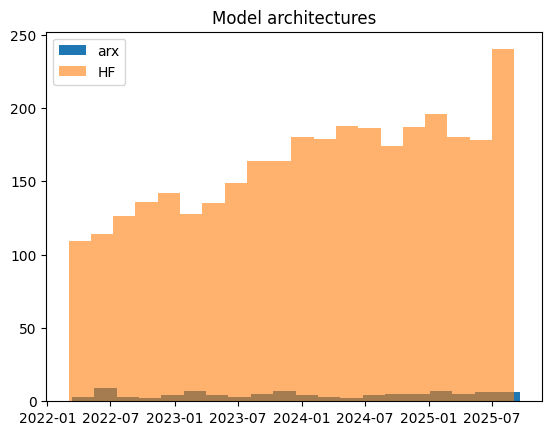

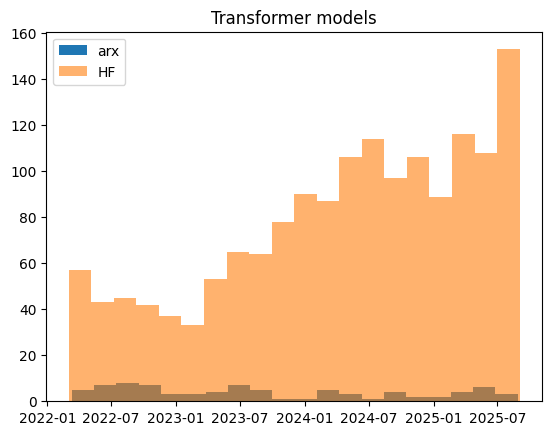

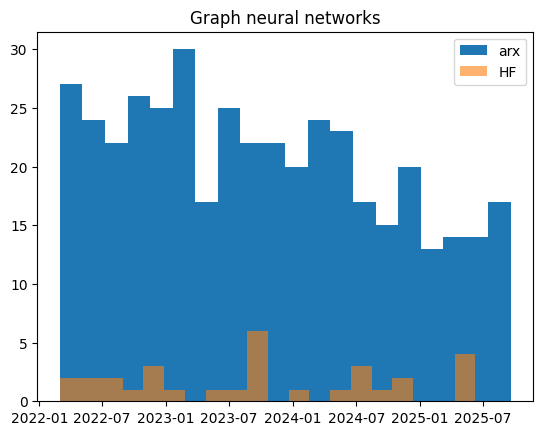

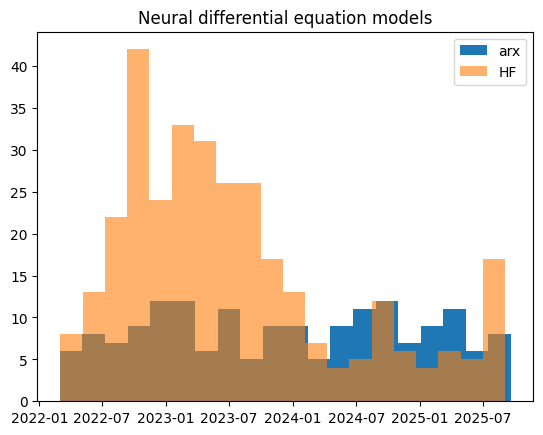

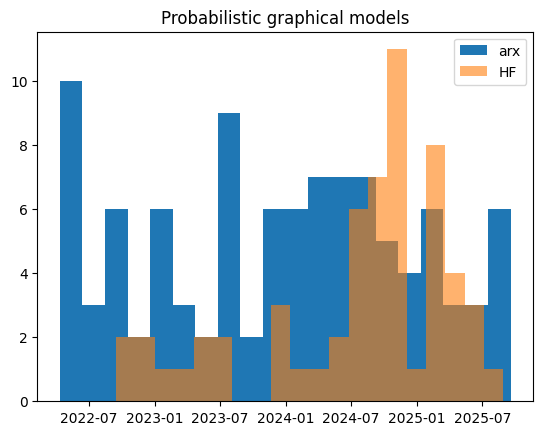

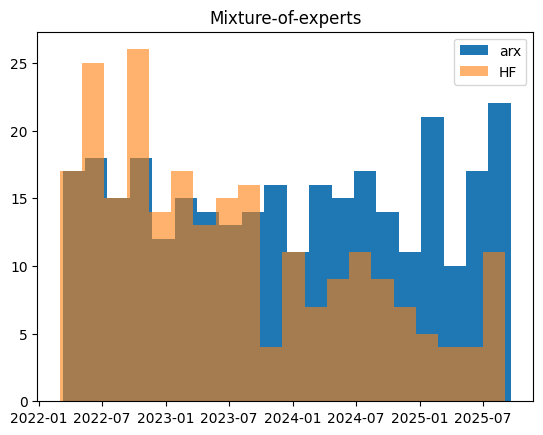

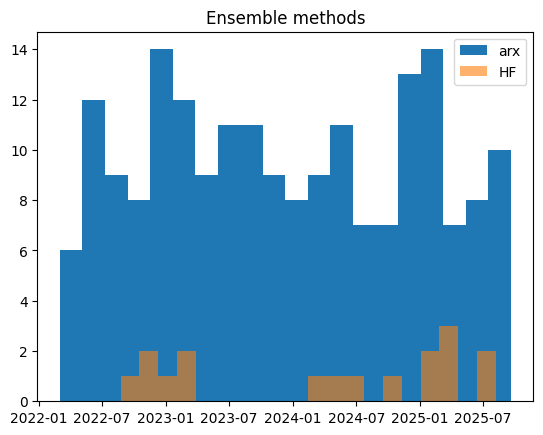

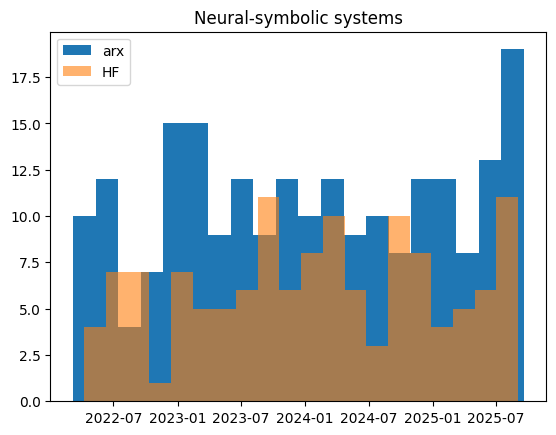

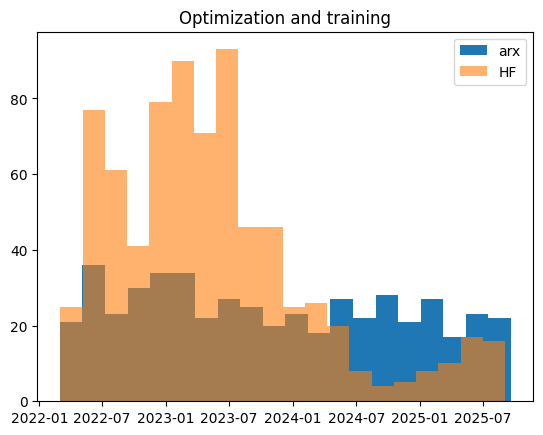

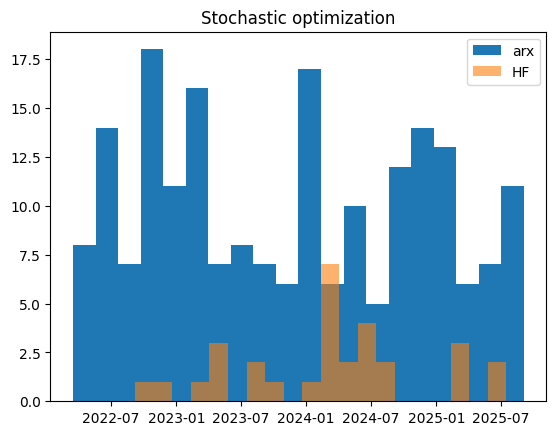

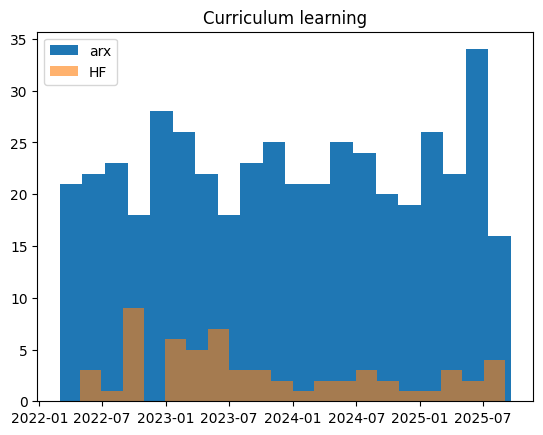

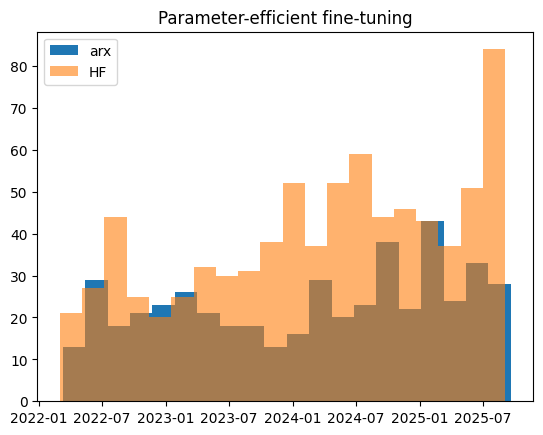

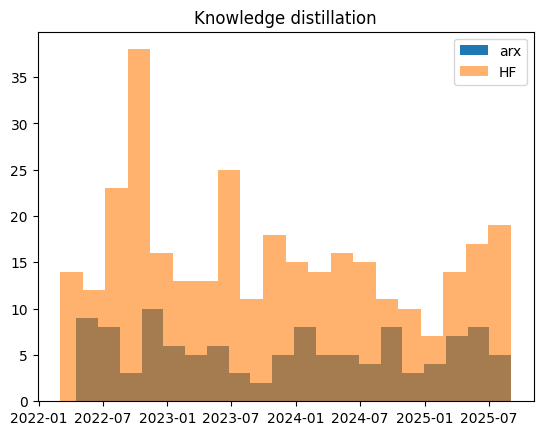

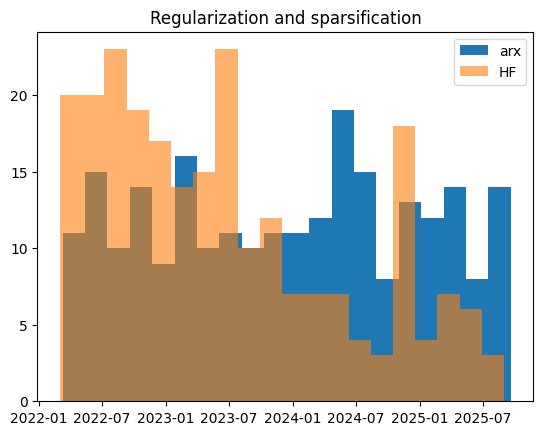

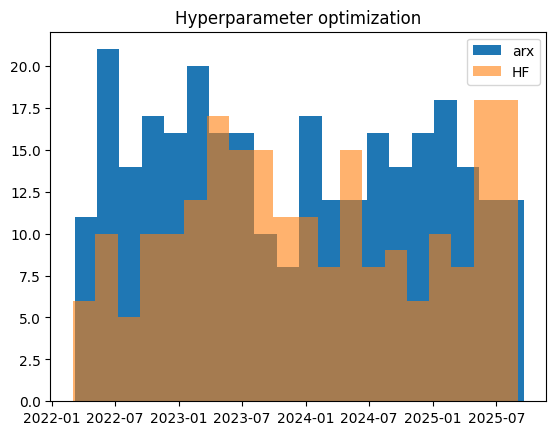

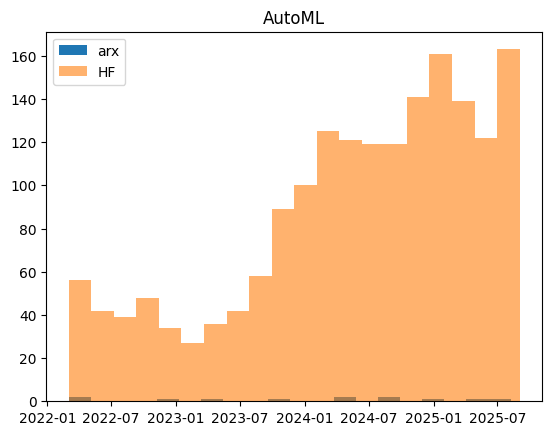

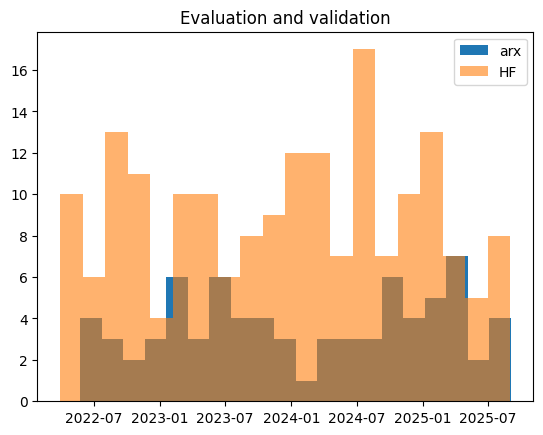

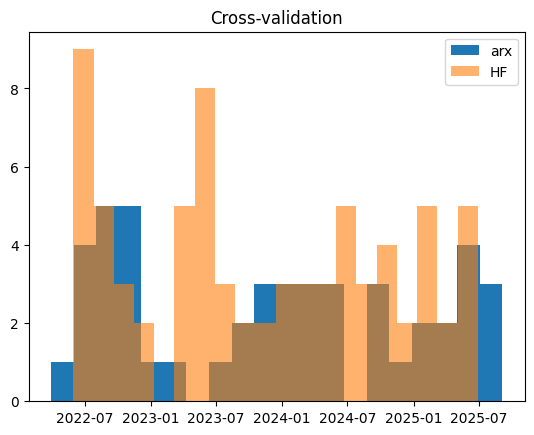

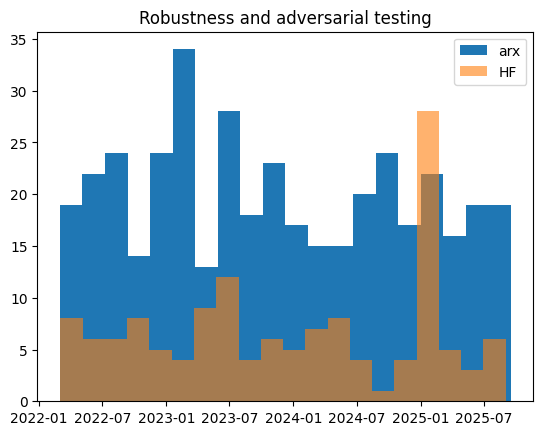

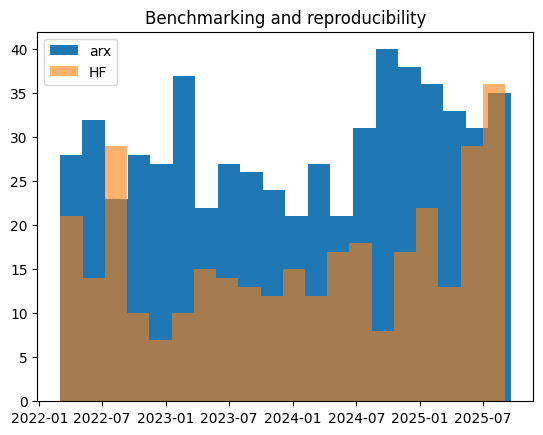

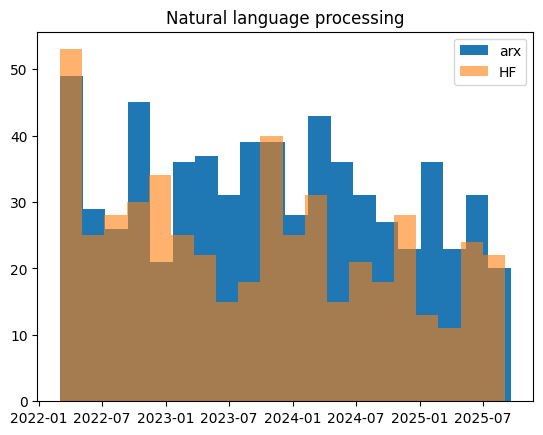

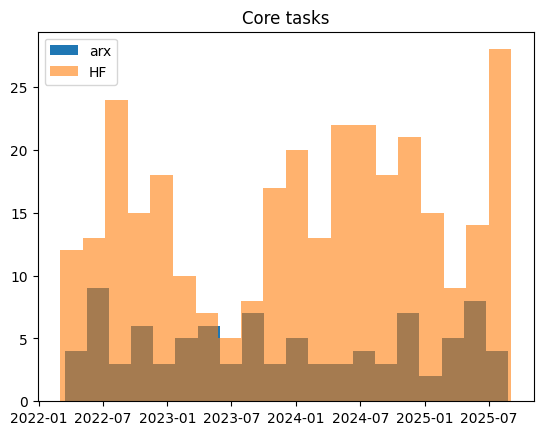

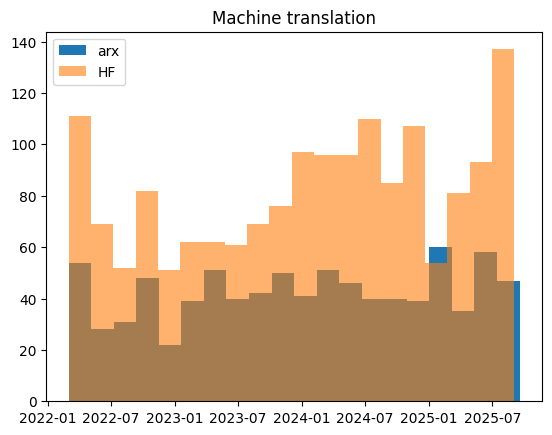

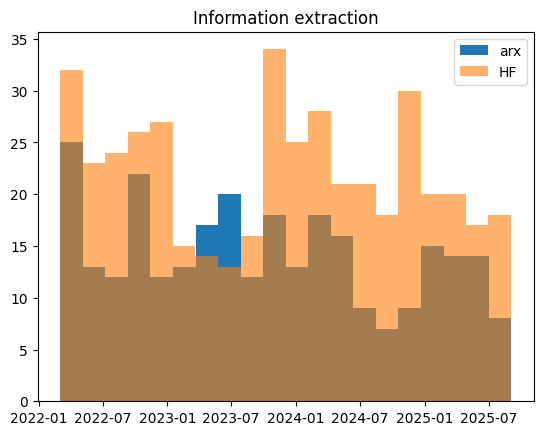

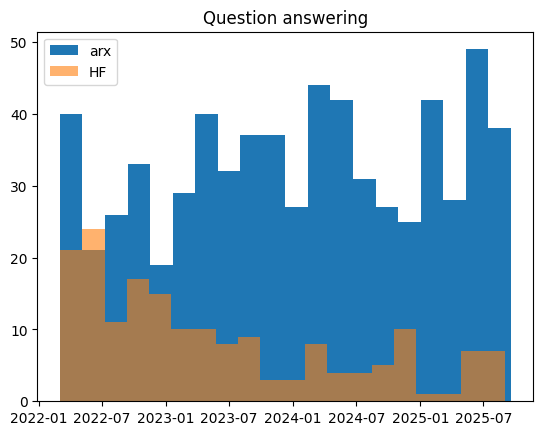

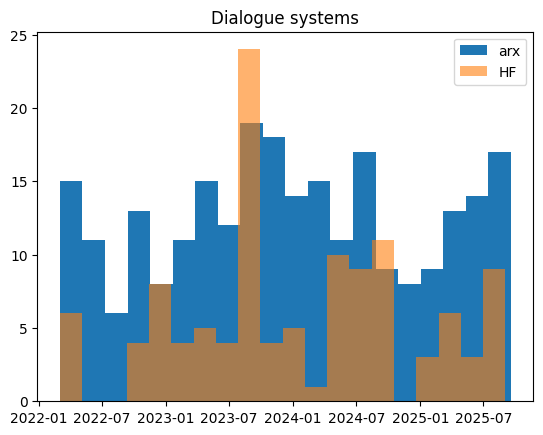

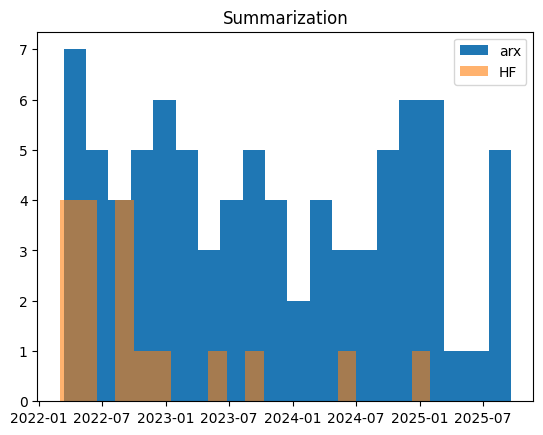

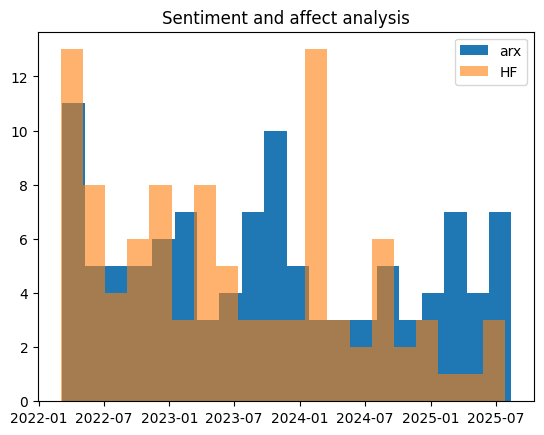

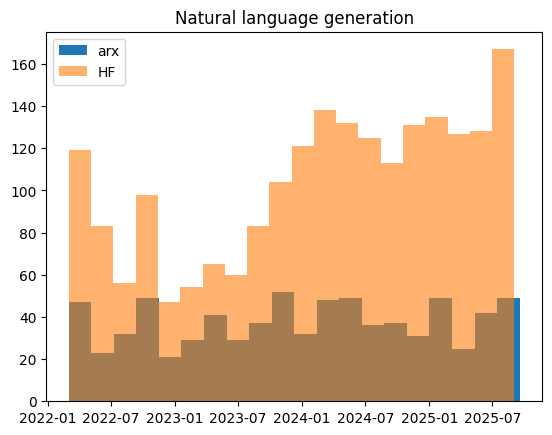

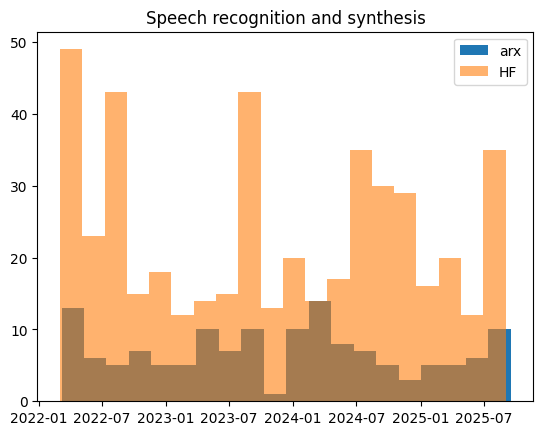

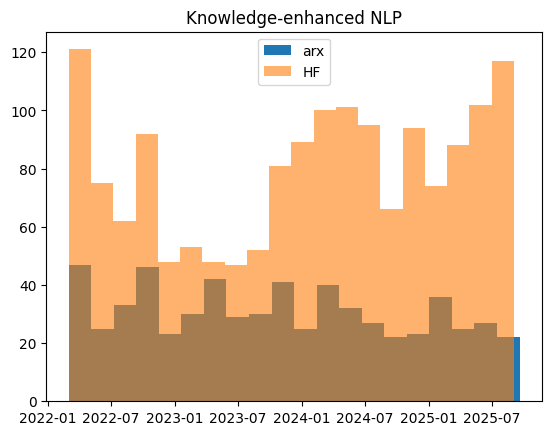

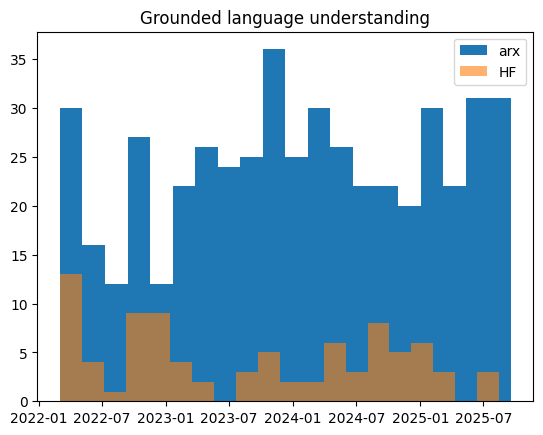

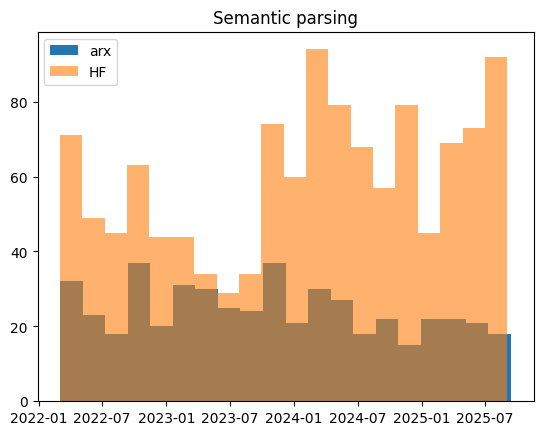

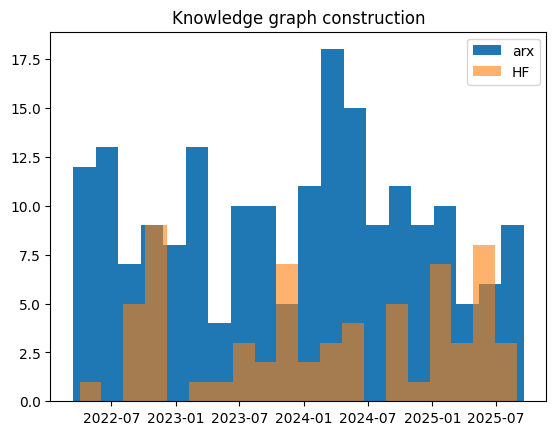

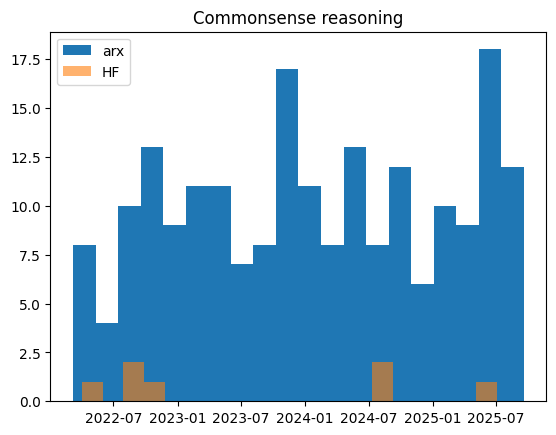

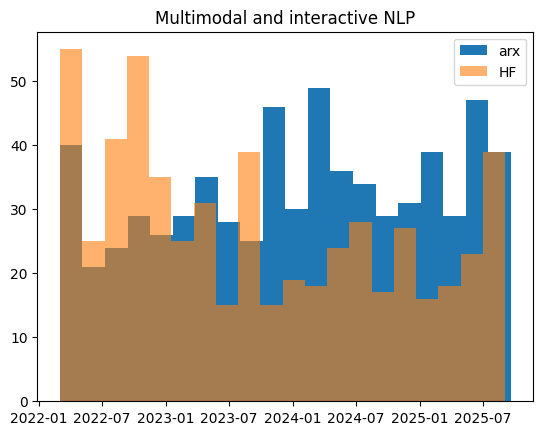

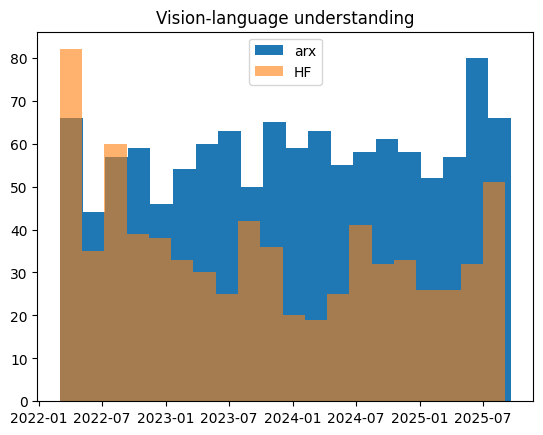

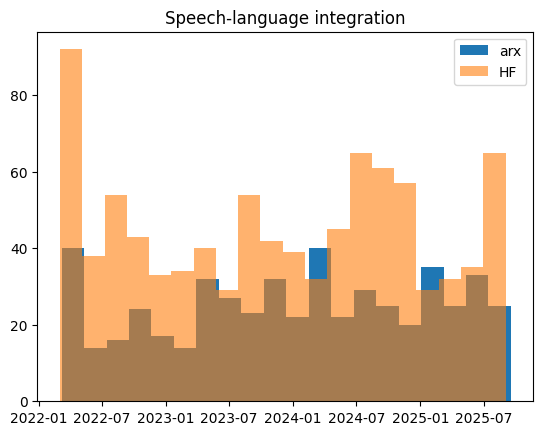

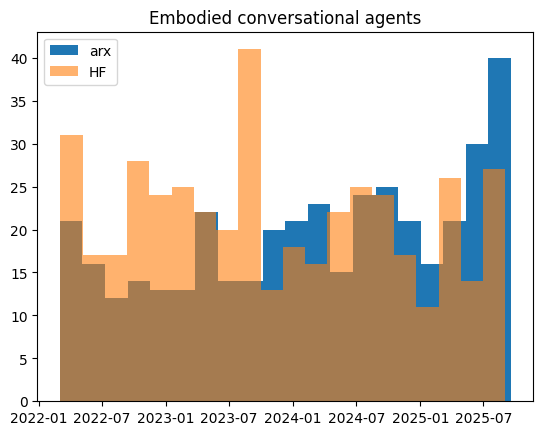

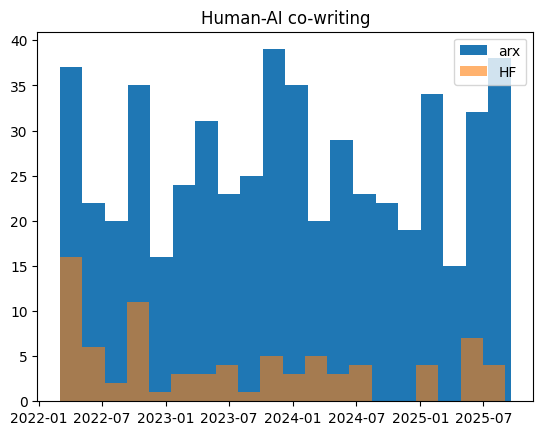

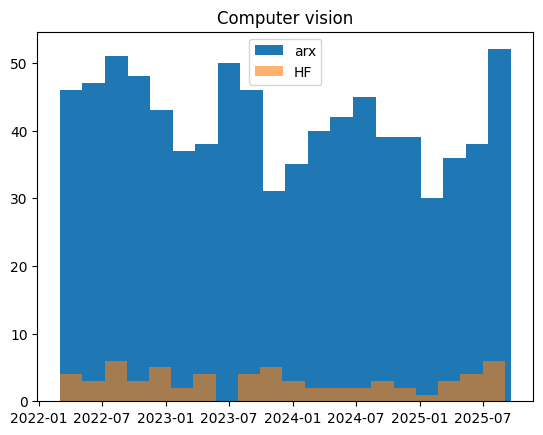

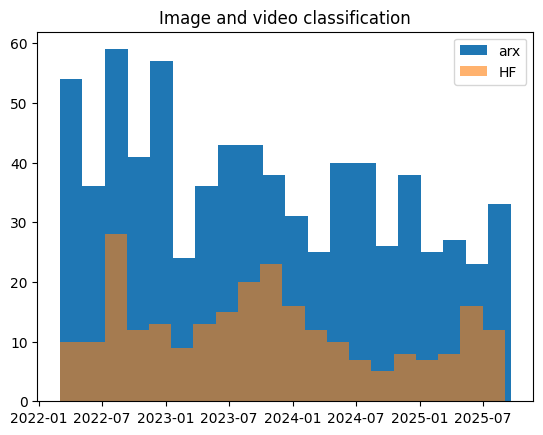

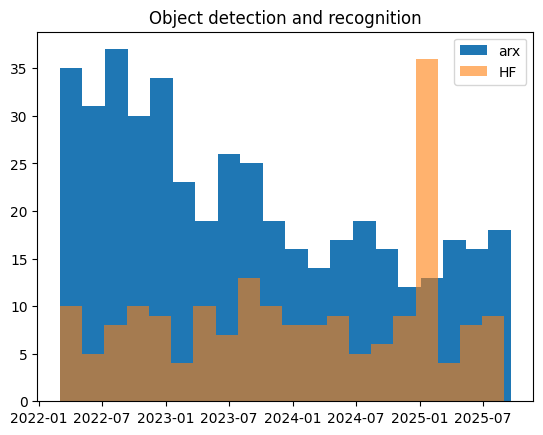

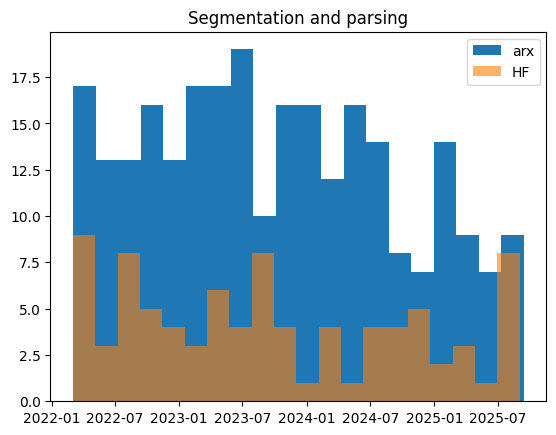

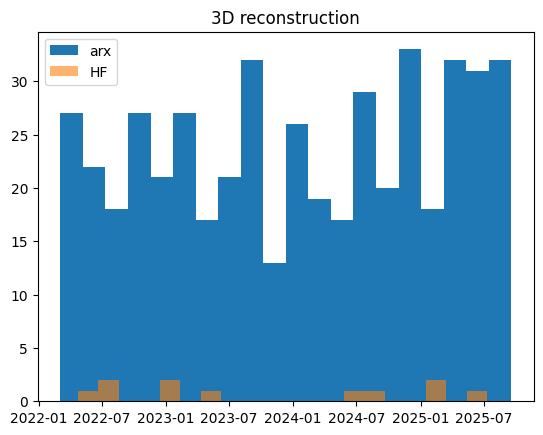

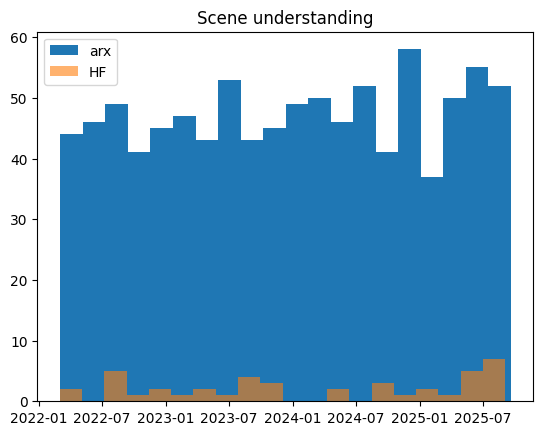

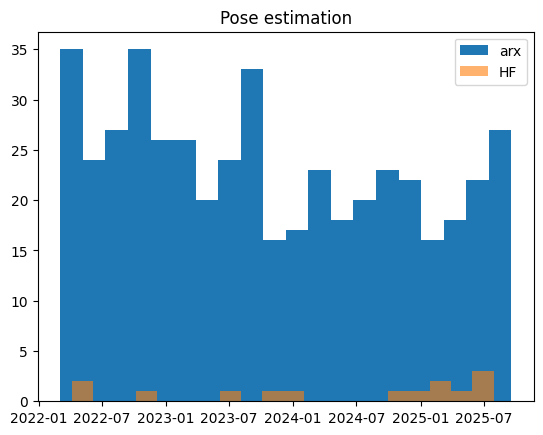

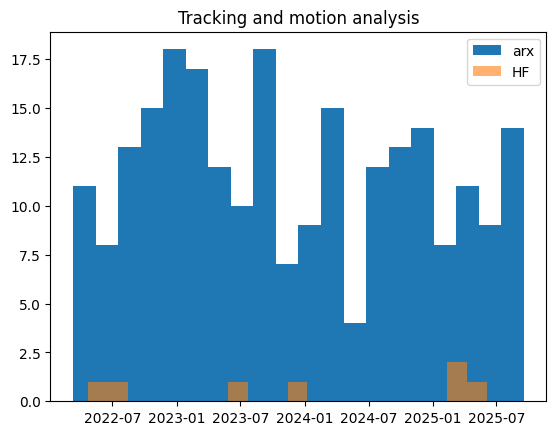

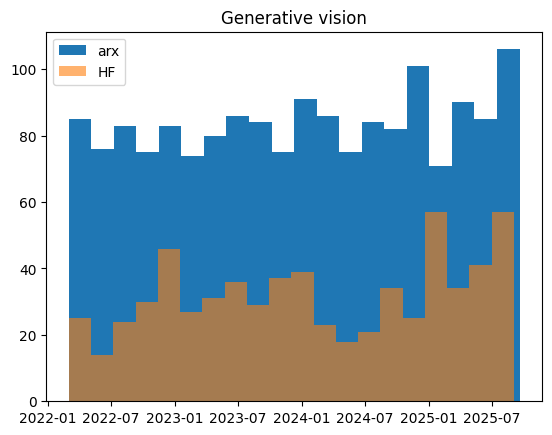

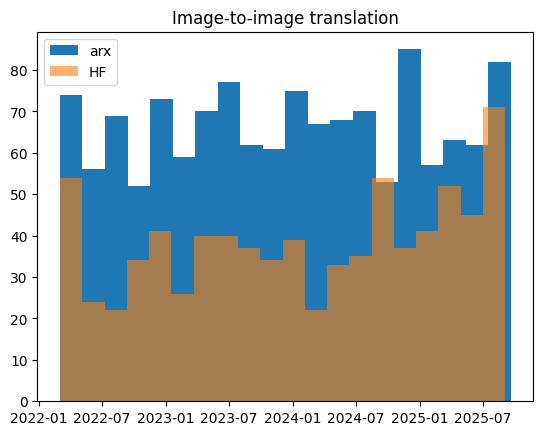

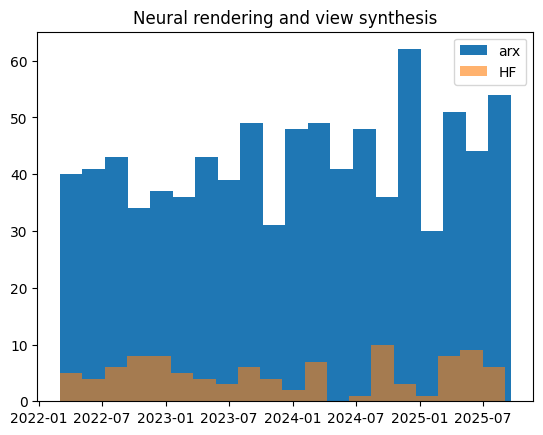

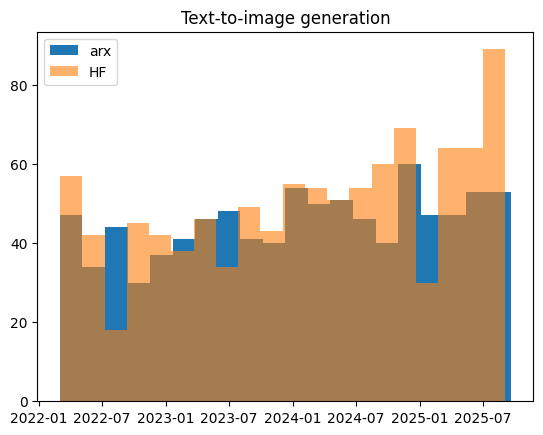

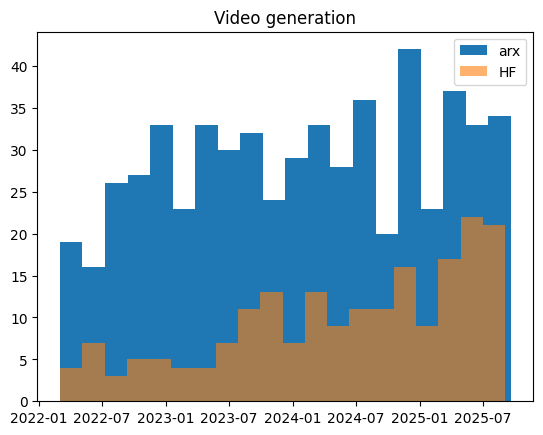

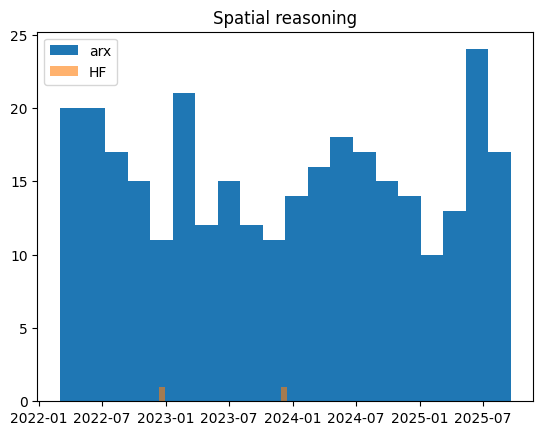

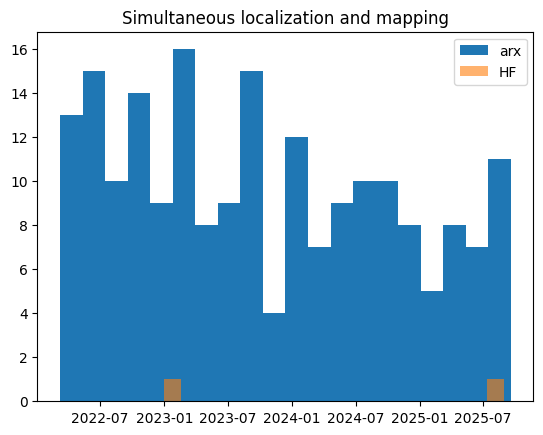

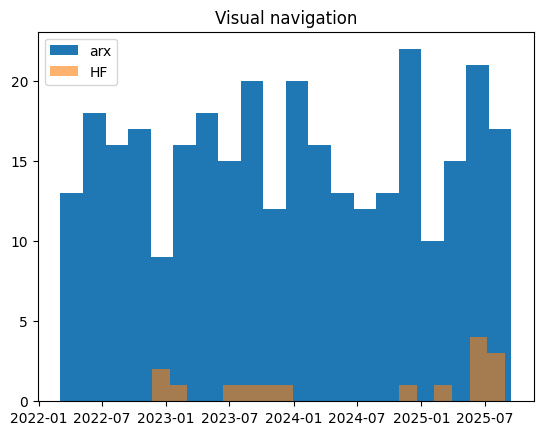

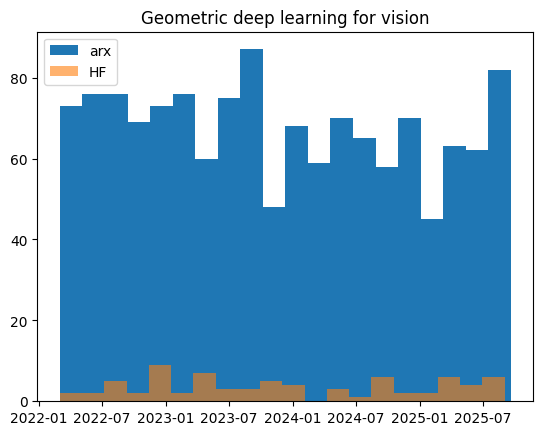

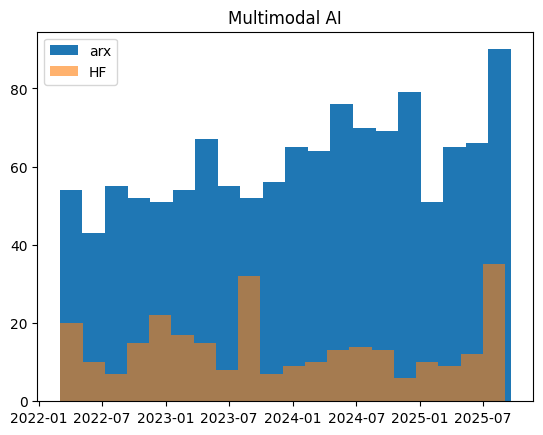

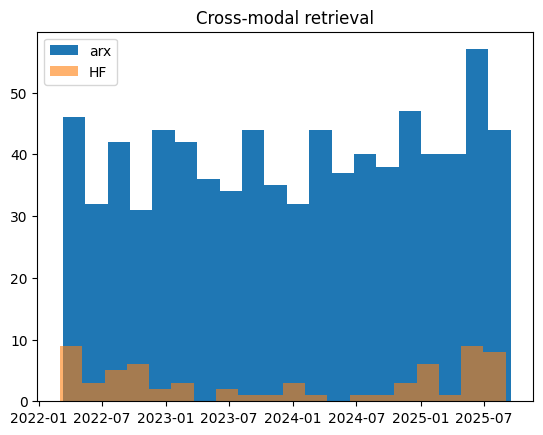

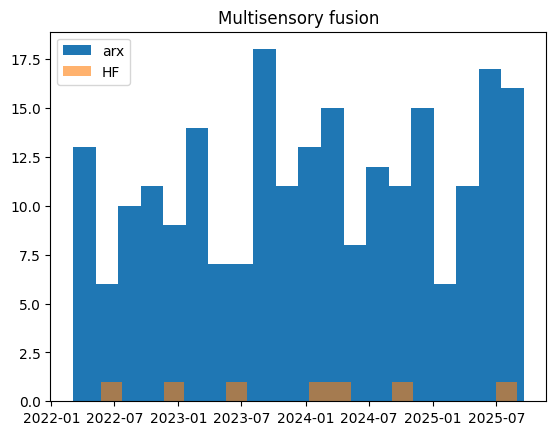

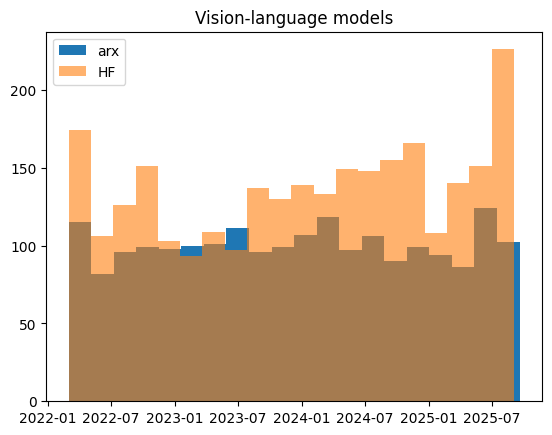

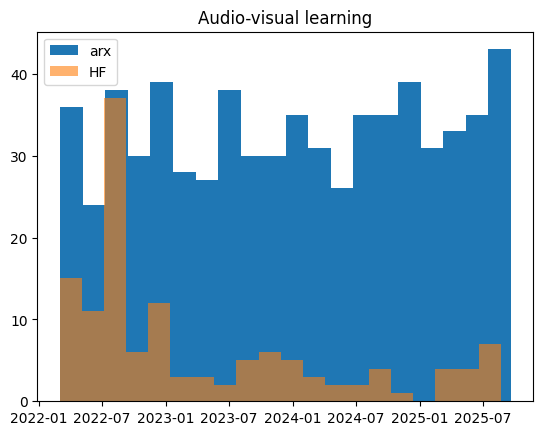

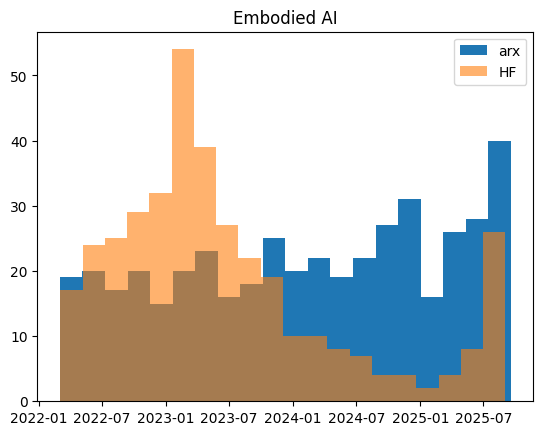

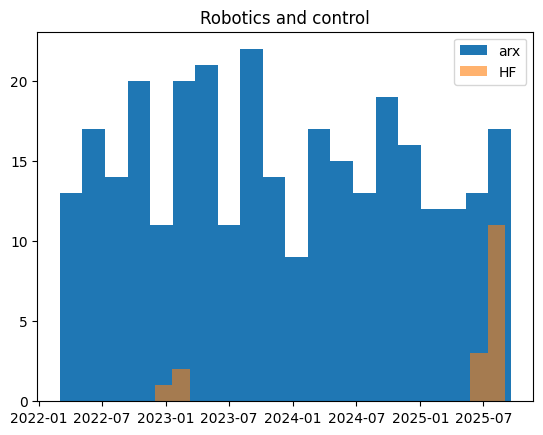

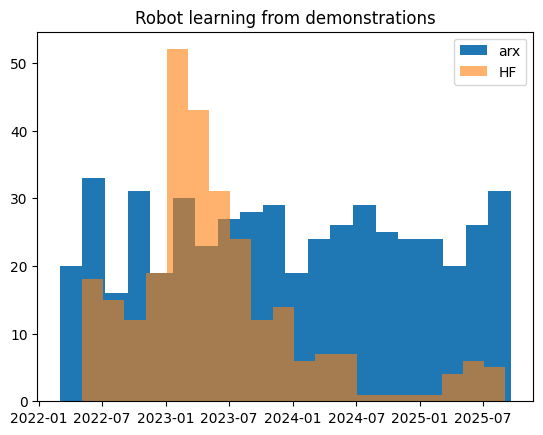

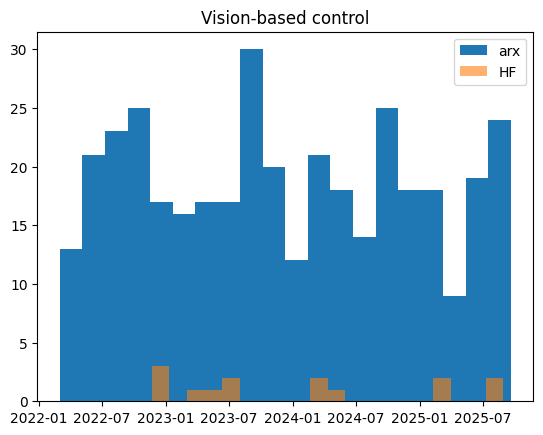

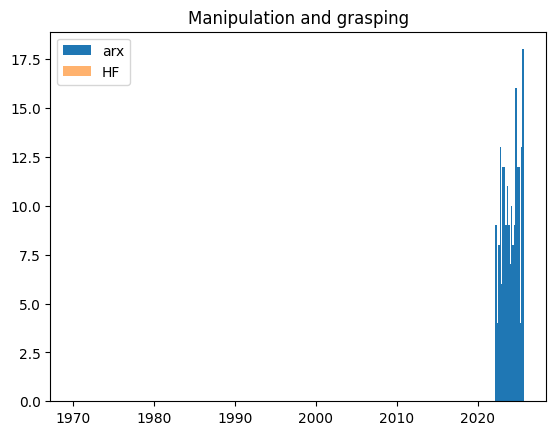

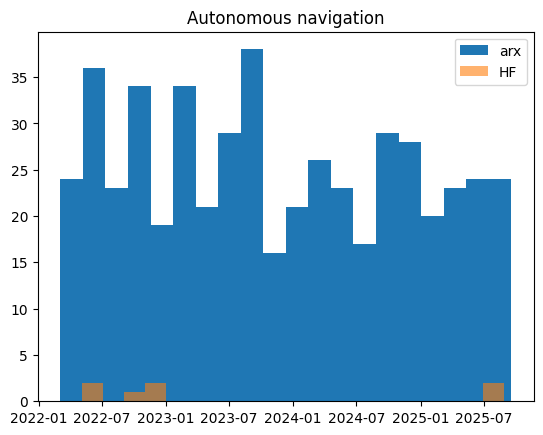

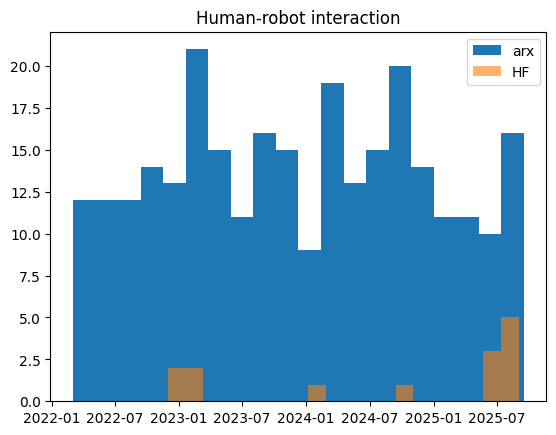

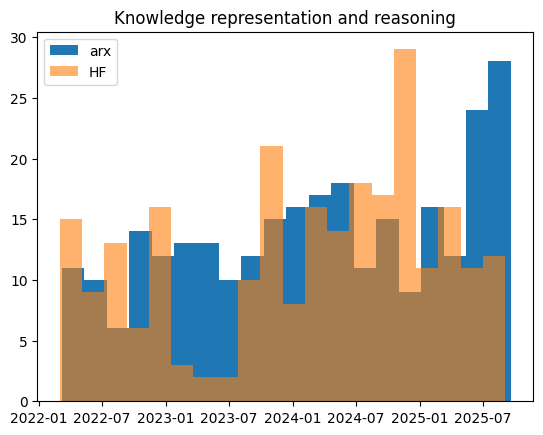

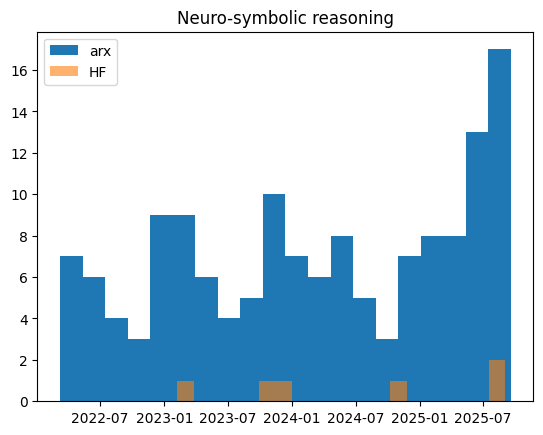

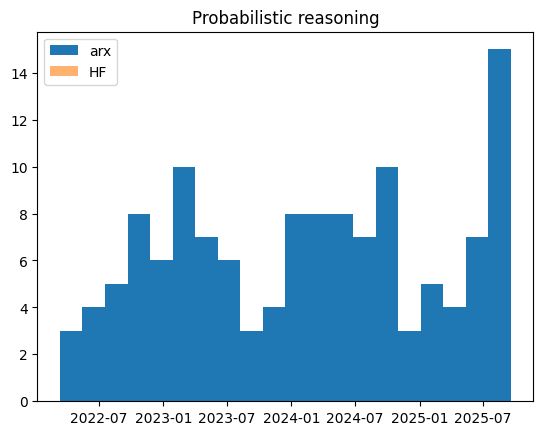

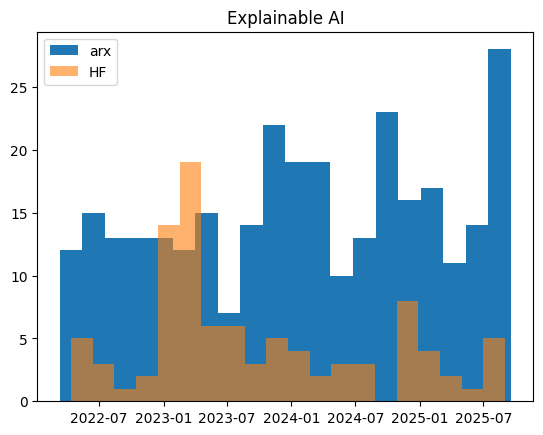

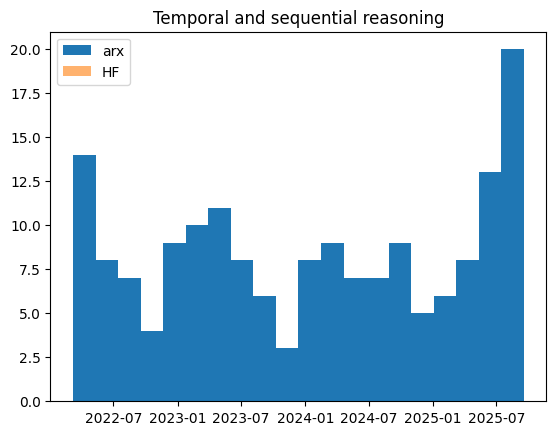

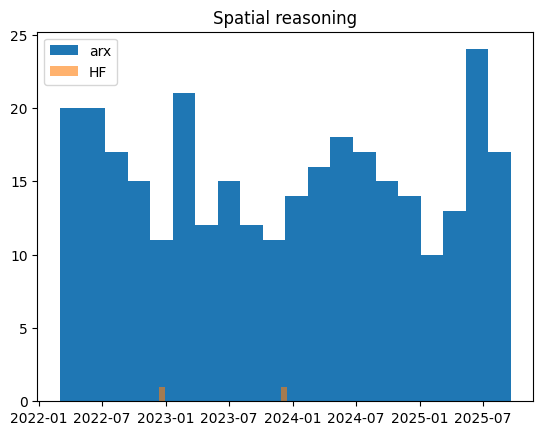

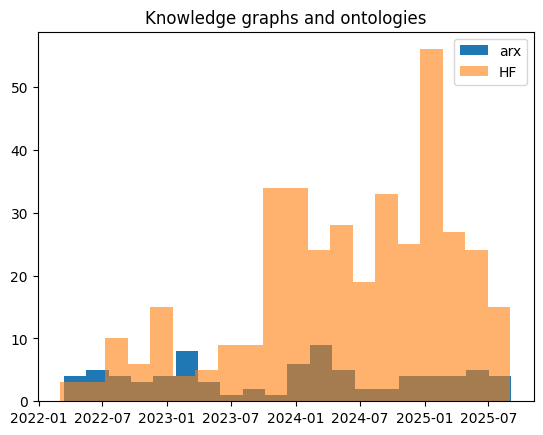

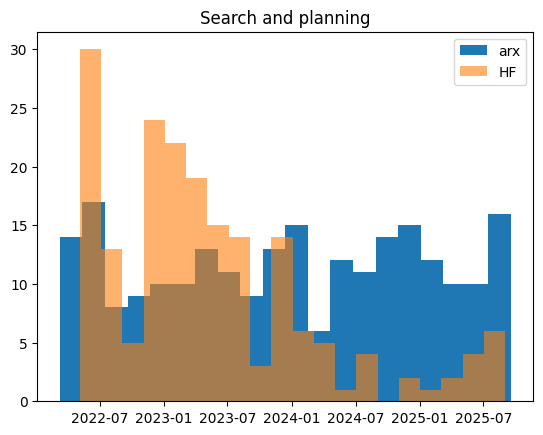

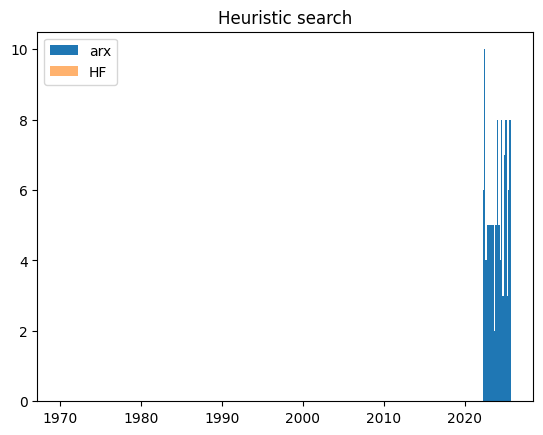

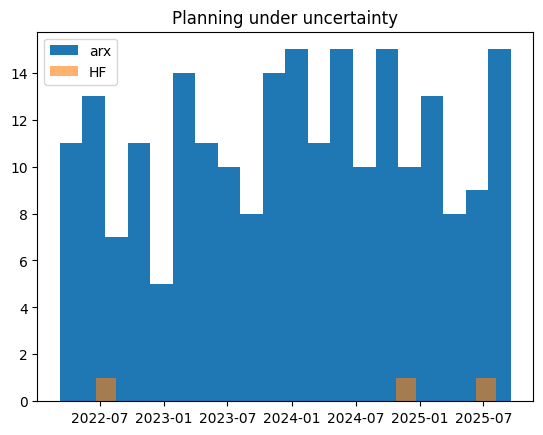

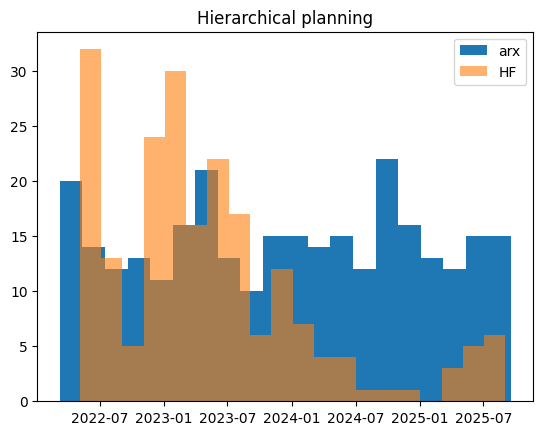

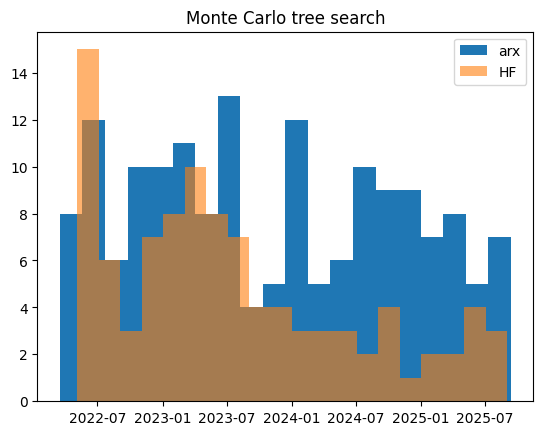

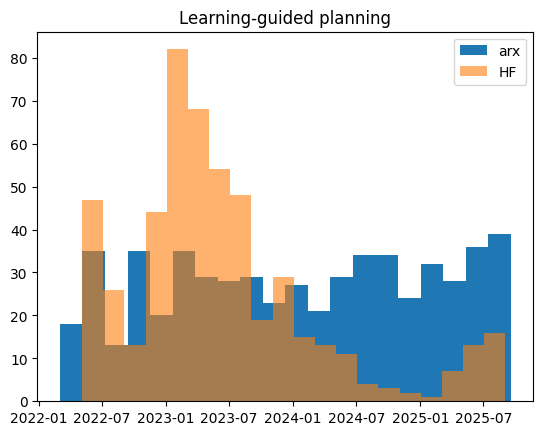

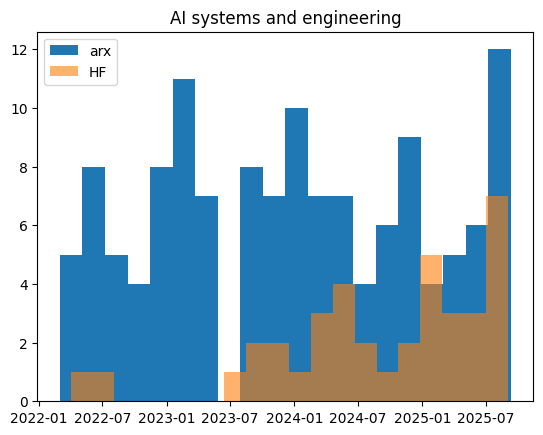

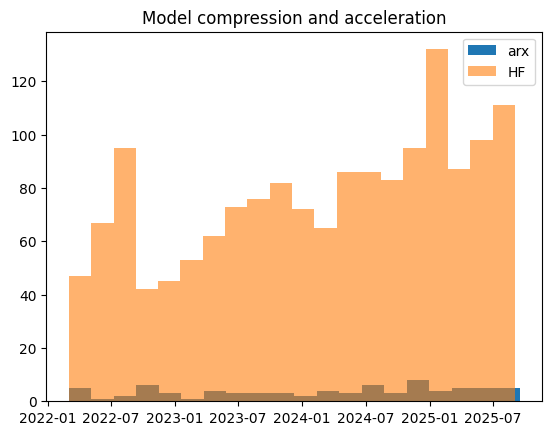

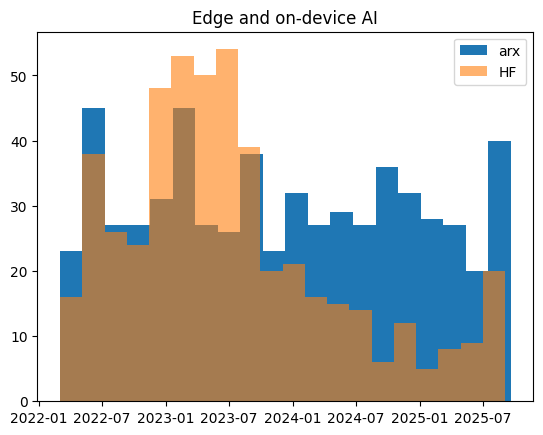

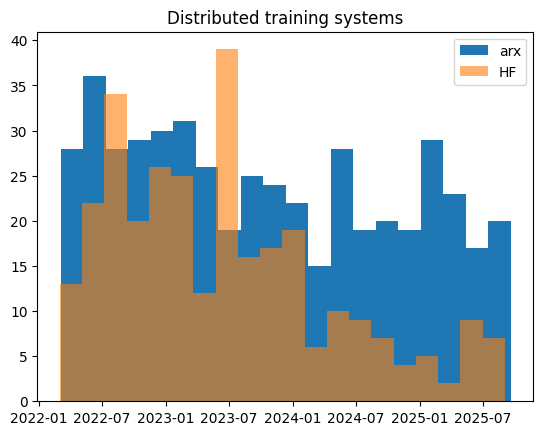

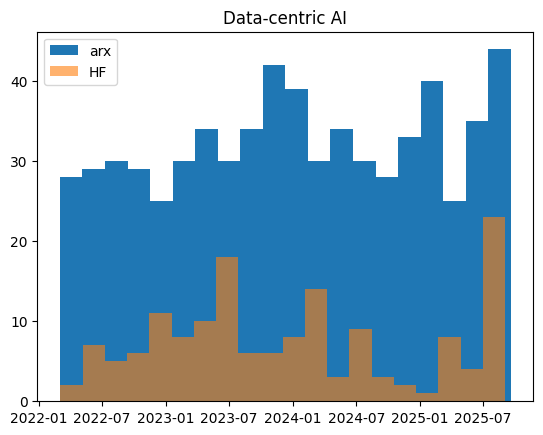

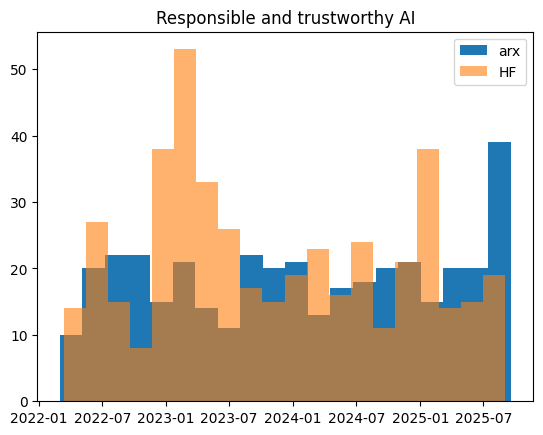

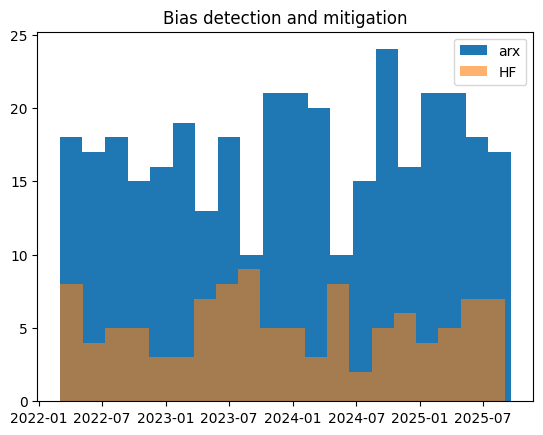

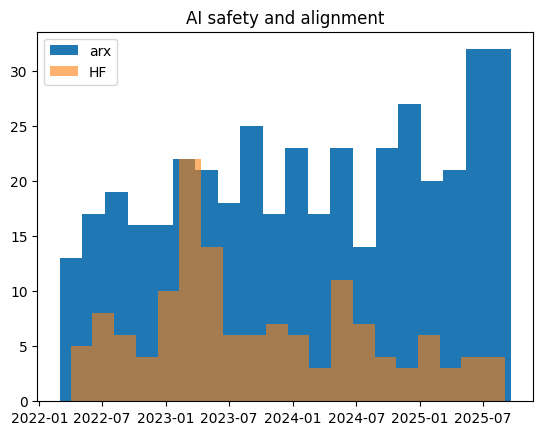

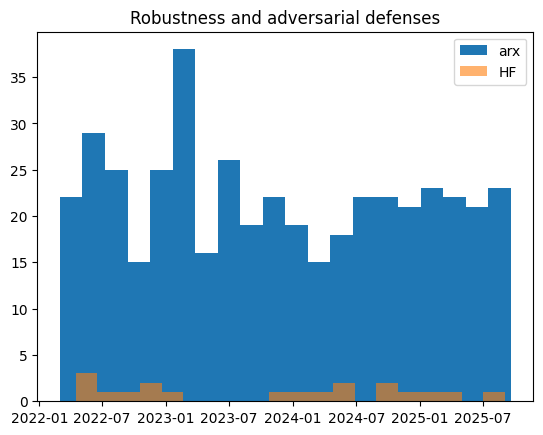

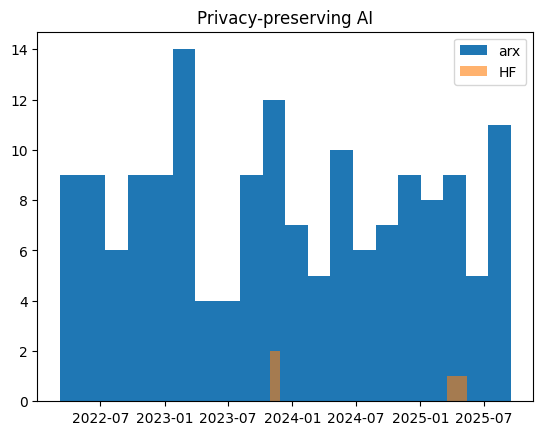

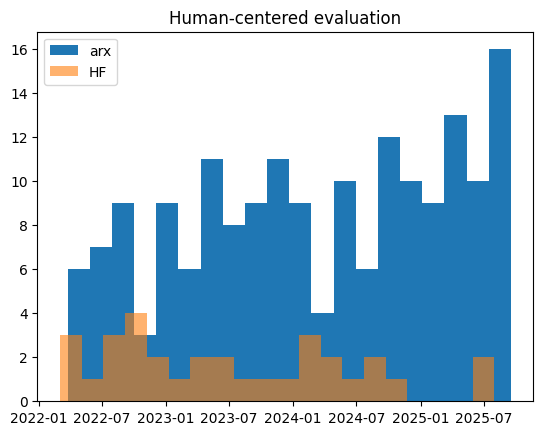

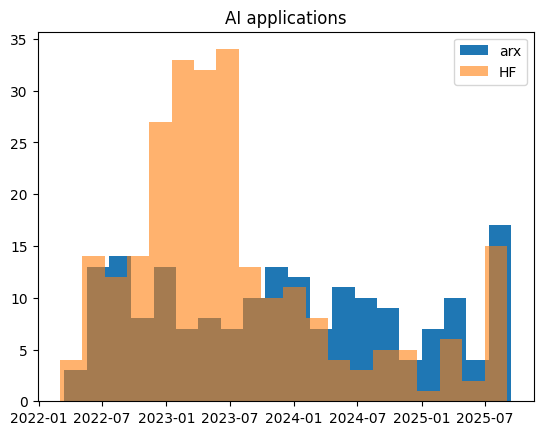

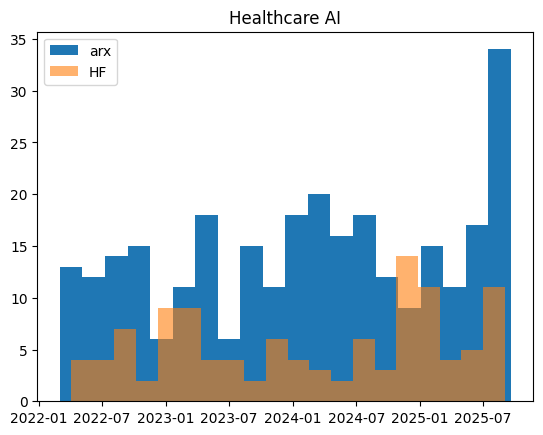

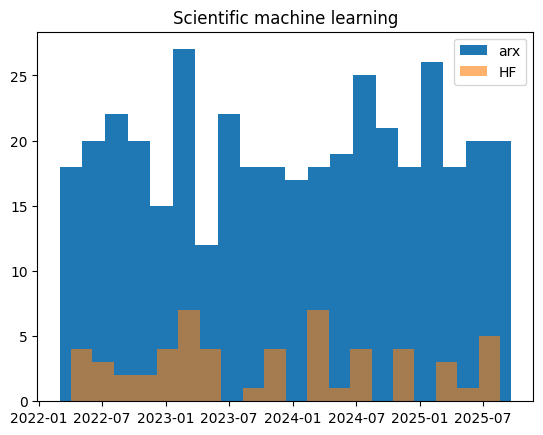

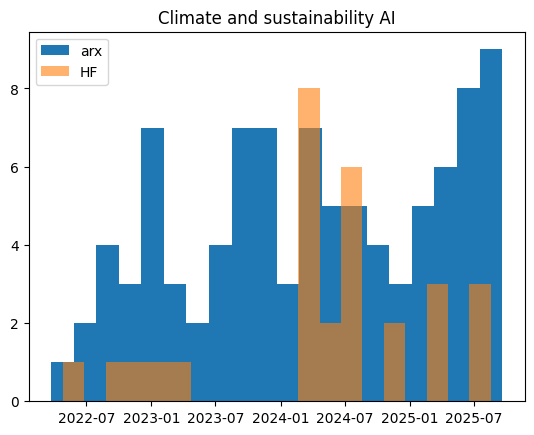

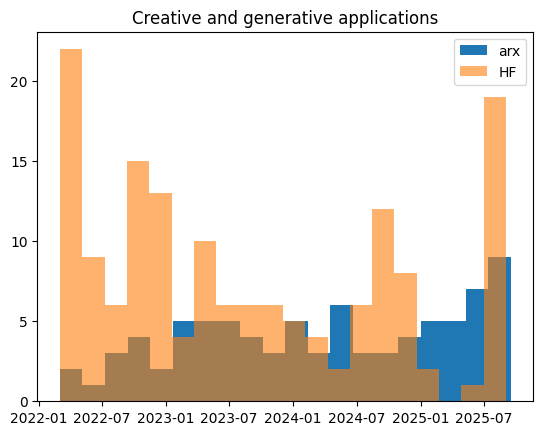

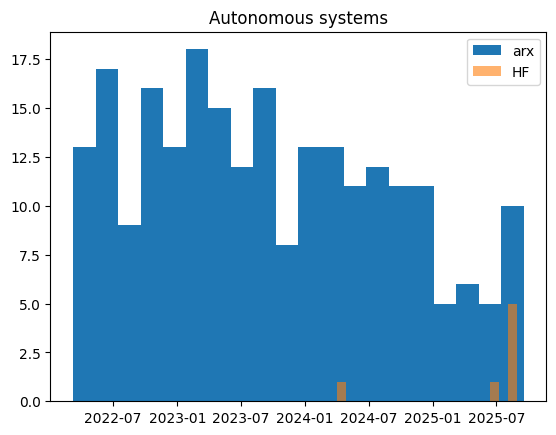

In [53]:
for term in ai_terms:
    plot_term(term, 15)
